Epoch 0: D Loss: 1.5370, G Loss: 1.3057, Sigma: 0.1000
Epoch 100: D Loss: 0.8246, G Loss: 1.3964, Sigma: 0.1000
Epoch 200: D Loss: 0.6689, G Loss: 1.5626, Sigma: 0.1000
Epoch 300: D Loss: 0.8108, G Loss: 1.4689, Sigma: 0.1000
Epoch 400: D Loss: 0.5904, G Loss: 1.6612, Sigma: 0.1000
Epoch 500: D Loss: 0.6994, G Loss: 1.4167, Sigma: 0.1000
Epoch 600: D Loss: 0.9639, G Loss: 1.4475, Sigma: 0.1000
Epoch 700: D Loss: 0.8739, G Loss: 1.3099, Sigma: 0.1000
Epoch 800: D Loss: 0.7545, G Loss: 1.4344, Sigma: 0.0999
Epoch 900: D Loss: 0.8001, G Loss: 1.3045, Sigma: 0.0998
Epoch 1000: D Loss: 0.8782, G Loss: 1.3711, Sigma: 0.0997
Epoch 1100: D Loss: 0.8296, G Loss: 1.3963, Sigma: 0.0996
Epoch 1200: D Loss: 0.9063, G Loss: 1.4119, Sigma: 0.0995
Epoch 1300: D Loss: 0.9520, G Loss: 1.3915, Sigma: 0.0993
Epoch 1400: D Loss: 0.9815, G Loss: 1.4122, Sigma: 0.0992
Epoch 1500: D Loss: 0.9856, G Loss: 1.4205, Sigma: 0.0991
Epoch 1600: D Loss: 1.0236, G Loss: 1.3840, Sigma: 0.0989
Epoch 1700: D Loss: 1.0314

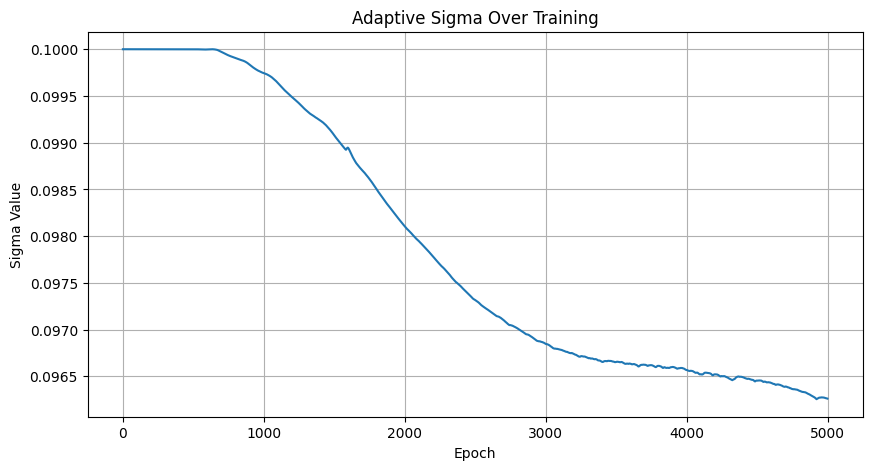

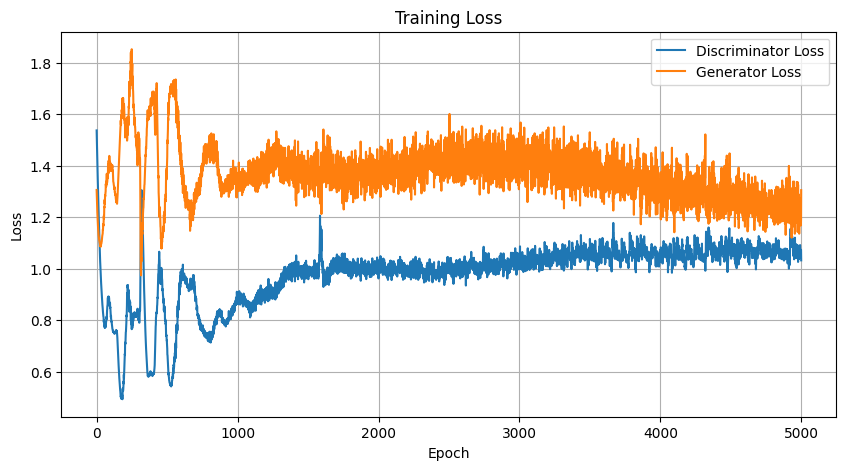

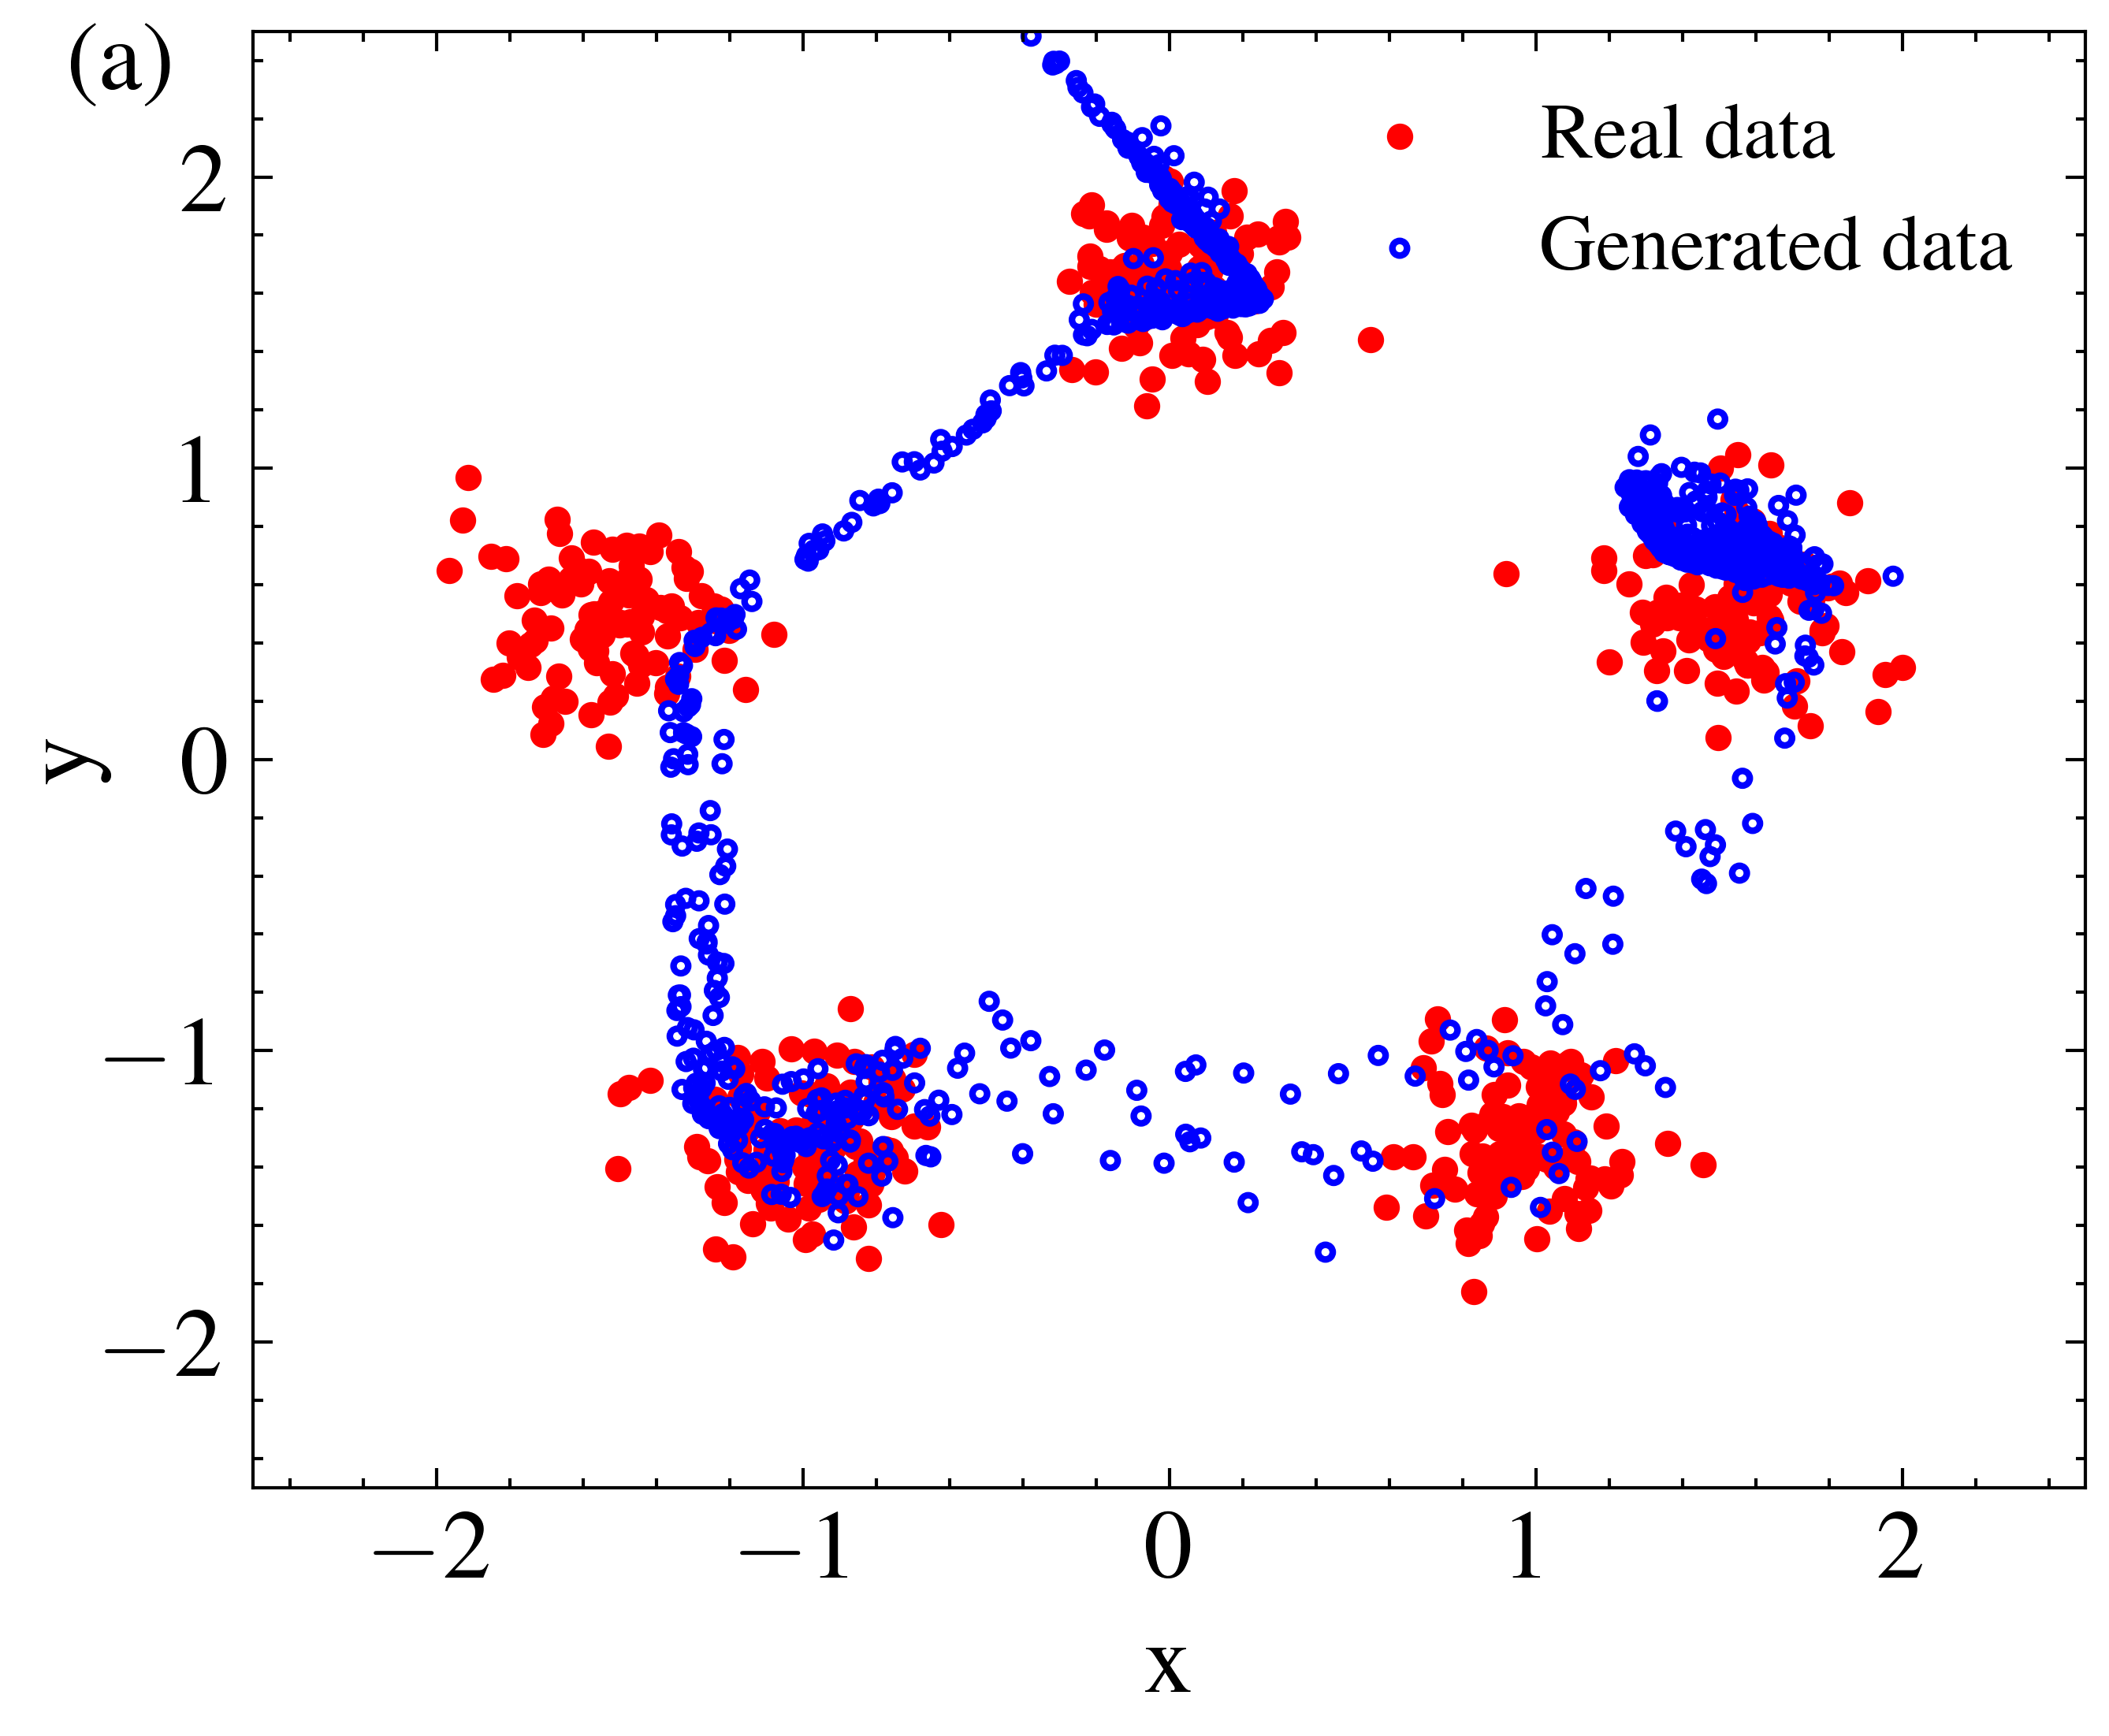

Final adaptive sigma value: 0.0963


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl

# 设置随机数种子
seed = 74  # 连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, init_sigma=0.1, min_sigma=0.09, max_sigma=0.15):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)
        
        # 使用更好的参数化方式，确保sigma受限在一个合理范围内
        # 使用 sigmoid 函数将参数映射到 [min_sigma, max_sigma] 范围
        self.min_sigma = min_sigma
        self.max_sigma = max_sigma
        
        # 计算初始的 raw_sigma 值，使得 sigmoid(raw_sigma) 对应到 init_sigma
        raw_init = -math.log((max_sigma - init_sigma) / (init_sigma - min_sigma))
        self.raw_sigma = nn.Parameter(torch.tensor(raw_init))
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def get_sigma(self):
        # 使用 sigmoid 函数将 raw_sigma 映射到 [min_sigma, max_sigma] 范围
        return self.min_sigma + (self.max_sigma - self.min_sigma) * torch.sigmoid(self.raw_sigma)

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        
        # 获取当前的 sigma 值（限制在 min_sigma 和 max_sigma 之间）
        sigma = self.get_sigma()
        
        # 使用自适应的 sigma 调整 sigmoid 函数的陡度
        output = self.sigmoid(d_y4 / sigma)
        return output, d_y4, sigma

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
sigma_lr = 1e-5  # 为 sigma 参数使用较小的学习率
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, init_sigma=0.1, min_sigma=0.08, max_sigma=0.2)

# 分离 sigma 参数和其他参数，使用不同的学习率
other_params = [p for n, p in discriminator.named_parameters() if n != 'raw_sigma']
sigma_params = [discriminator.raw_sigma]

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam([
    {'params': other_params, 'lr': learning_rate},
    {'params': sigma_params, 'lr': sigma_lr}
])

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []
sigma_values = []  # 记录每个epoch的sigma值

# 添加早期稳定阶段：前N个epoch固定sigma
early_stabilize_epochs = 500
warmup_epochs = 1000  # sigma学习率从0逐渐增加的阶段

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_sigma_values = []
    nb_batches = int(X_train.shape[0] / batch_size)

    # 早期稳定：暂时禁用sigma参数的梯度
    if epoch < early_stabilize_epochs:
        discriminator.raw_sigma.requires_grad = False
    else:
        discriminator.raw_sigma.requires_grad = True
        
        # 实现学习率的预热
        if epoch < early_stabilize_epochs + warmup_epochs:
            progress = (epoch - early_stabilize_epochs) / warmup_epochs
            for param_group in d_optimizer.param_groups:
                if param_group['params'] == sigma_params:
                    param_group['lr'] = sigma_lr * progress

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _, current_sigma = discriminator(image_batch)
        d_fake, _, _ = discriminator(fake_img.detach())

        # 记录当前的sigma值
        batch_sigma_values.append(current_sigma.item())
        
        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    sigma_values.append(np.mean(batch_sigma_values))

    # Print losses and sigma every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}, Sigma: {np.mean(batch_sigma_values):.4f}")

# 可视化 sigma 值的变化
plt.figure(figsize=(10, 5))
plt.plot(sigma_values)
plt.xlabel('Epoch')
plt.ylabel('Sigma Value')
plt.title('Adaptive Sigma Over Training')
plt.grid(True)
plt.show()

# 绘制训练过程中的损失
plt.figure(figsize=(10, 5))
plt.plot(epoch_discriminator_loss, label='Discriminator Loss')
plt.plot(epoch_generator_loss, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

# 设置绘图参数
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['science','ieee'])

# 生成 GAN 的输出数据
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue', s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)

# 显示图 (a)
plt.show()

print(f"Final adaptive sigma value: {sigma_values[-1]:.4f}")

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


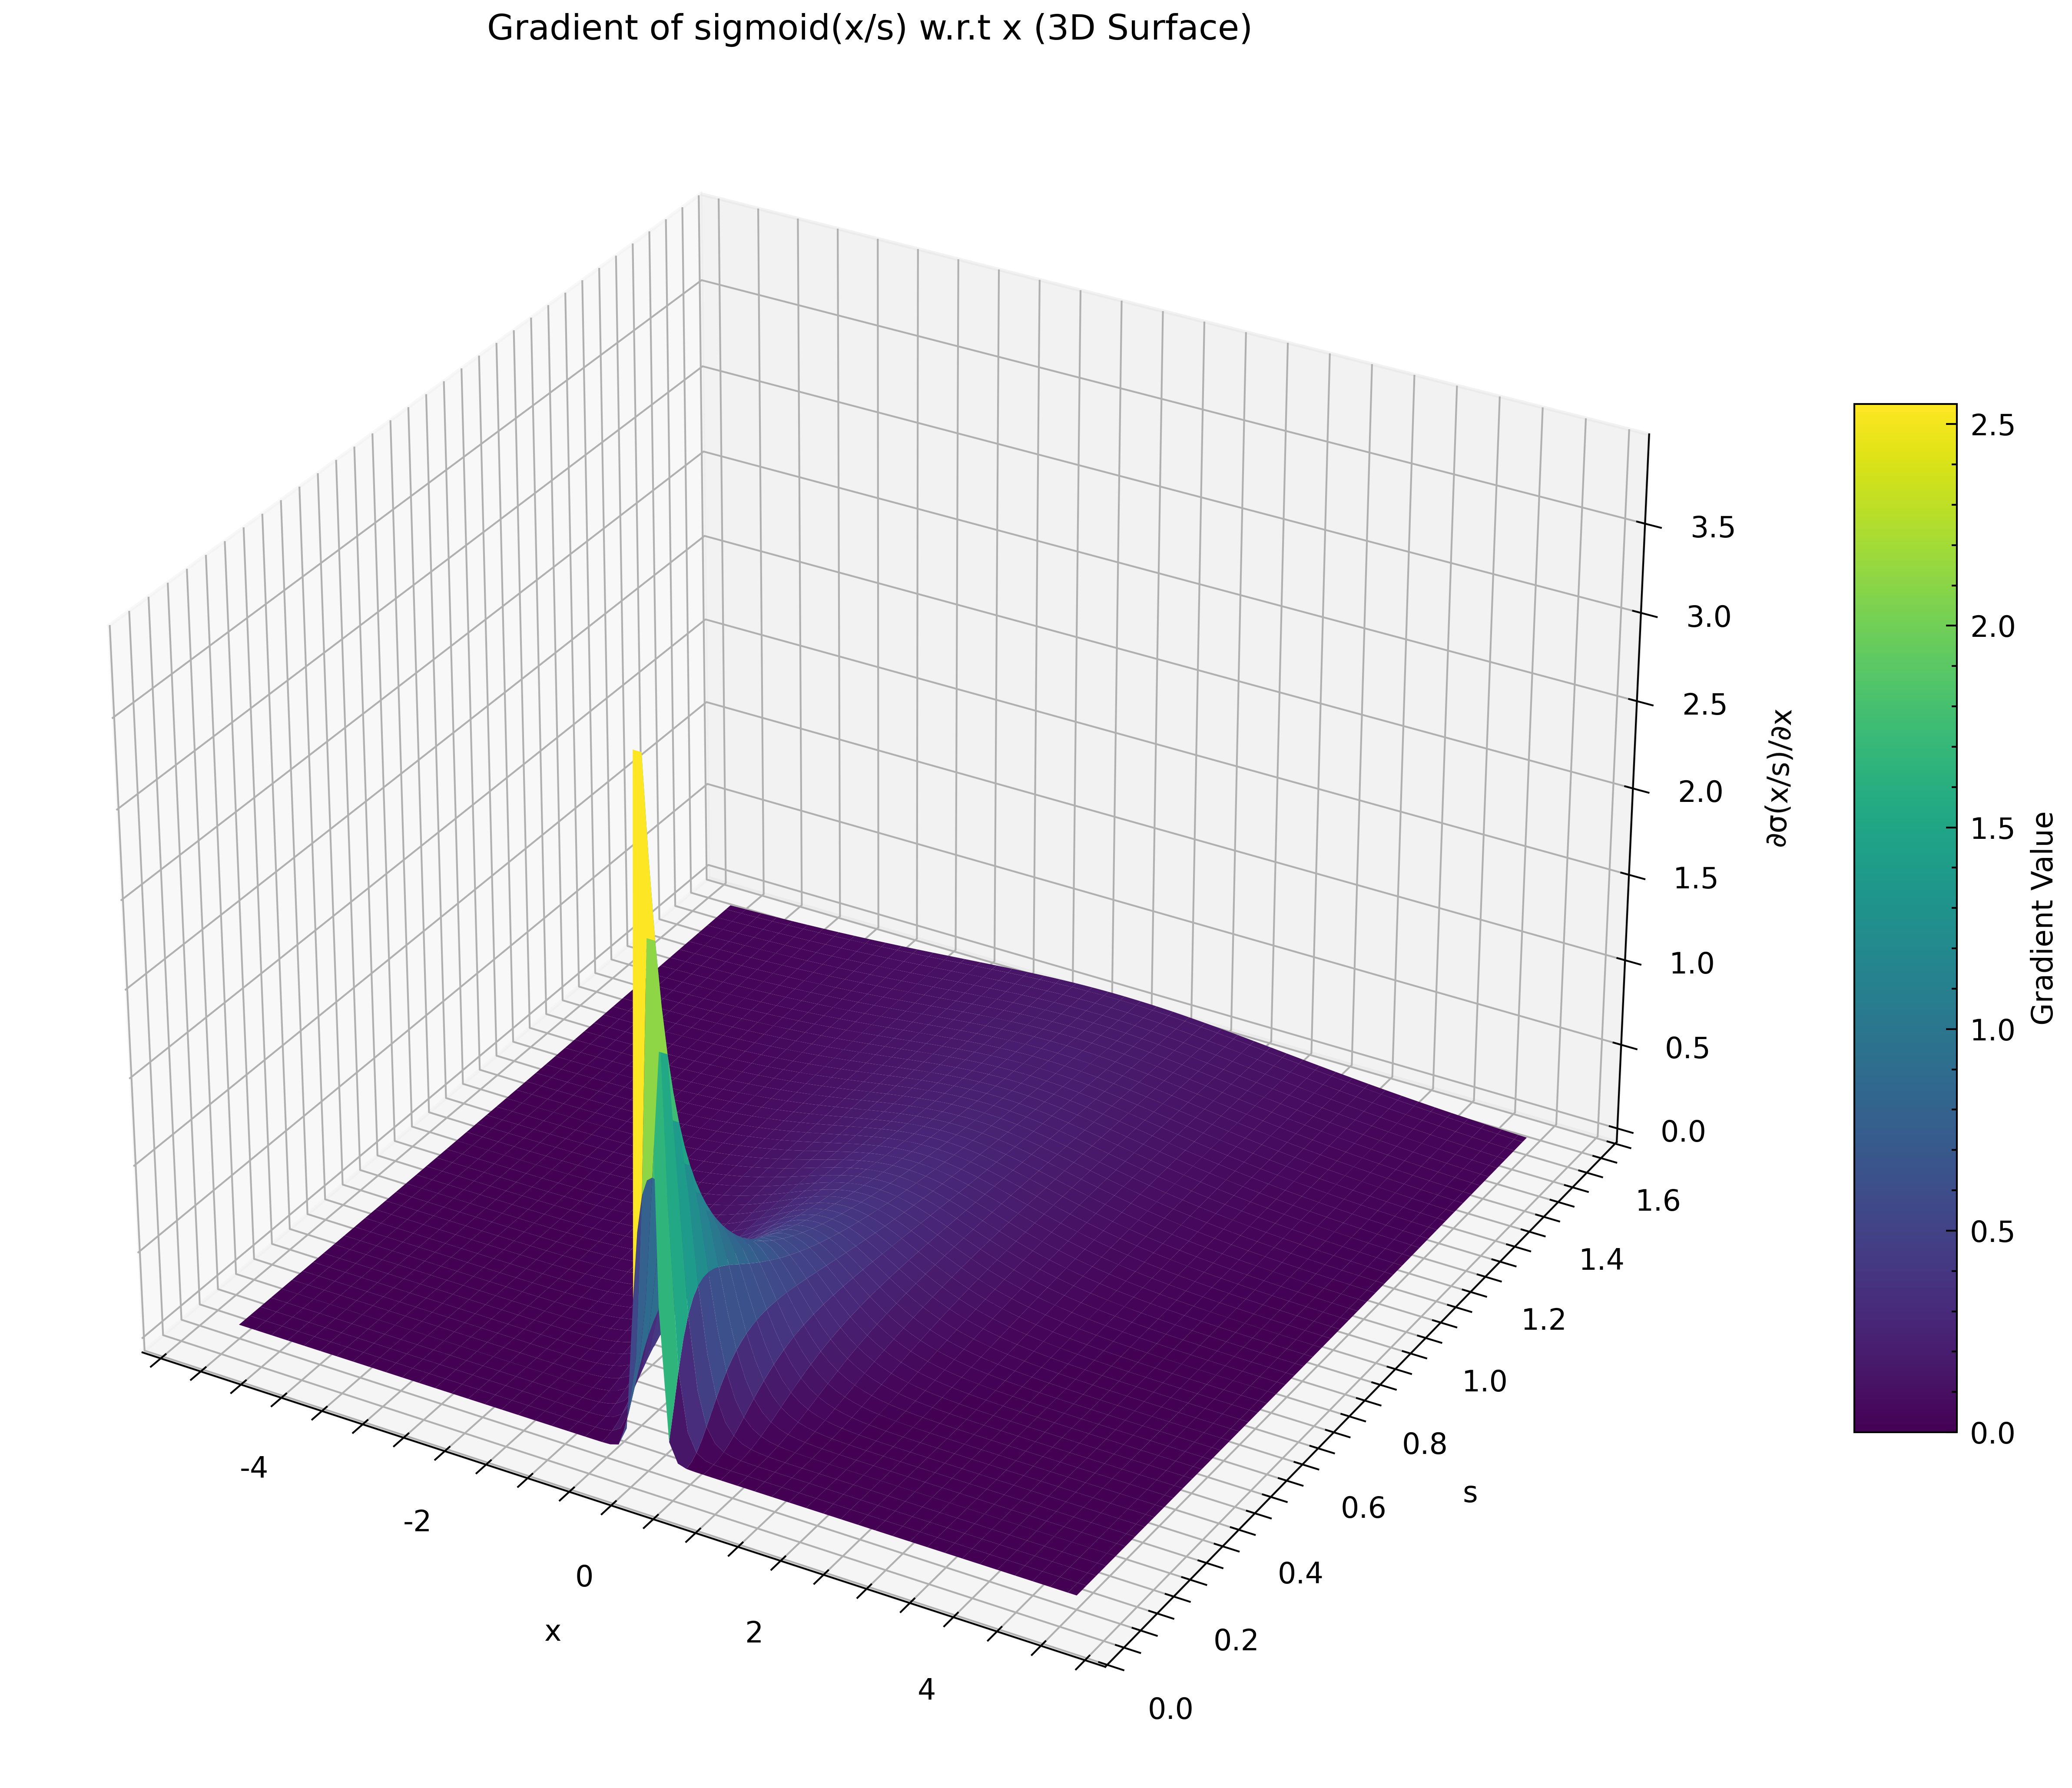

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False  # 禁用 LaTeX 渲染

# 定义x和s的取值范围
x_vals = torch.linspace(-5, 5, 100)
s_vals = torch.linspace(0.05, 1.5, 100)

# 创建网格
X, S = torch.meshgrid(x_vals, s_vals, indexing='xy')

# 计算 sigmoid(x/s) 的梯度 d/dx
X_scaled = X / S
sigmoid = torch.sigmoid(X_scaled)
grad = sigmoid * (1 - sigmoid) / S  # d/dx σ(x/s) = σ(x/s) * (1 - σ(x/s)) * (1/s)

# 转换为 numpy 格式用于绘图
X_np = X.numpy()
S_np = S.numpy()
grad_np = grad.numpy()

# 绘制 3D 曲面图
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X_np, S_np, grad_np, cmap='viridis', edgecolor='none')

# 添加标签
ax.set_title('Gradient of sigmoid(x/s) w.r.t x (3D Surface)')
ax.set_xlabel('x')
ax.set_ylabel('s')
ax.set_zlabel('∂σ(x/s)/∂x')
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label='Gradient Value')

plt.tight_layout()
plt.show()


Epoch 0: D Loss: 1.3821, G Loss: 0.7446
Epoch 100: D Loss: 1.1944, G Loss: 0.8948
Epoch 200: D Loss: 0.9728, G Loss: 1.0059
Epoch 300: D Loss: 1.5890, G Loss: 0.7007
Epoch 400: D Loss: 1.1606, G Loss: 1.1271
Epoch 500: D Loss: 1.3160, G Loss: 0.8378
Epoch 600: D Loss: 1.6119, G Loss: 0.4550
Epoch 700: D Loss: 1.3456, G Loss: 1.0529
Epoch 800: D Loss: 0.9103, G Loss: 1.0589
Epoch 900: D Loss: 1.5372, G Loss: 0.7616
Epoch 1000: D Loss: 0.9055, G Loss: 1.0577
Epoch 1100: D Loss: 0.7322, G Loss: 1.4177
Epoch 1200: D Loss: 1.3234, G Loss: 0.7447
Epoch 1300: D Loss: 1.0330, G Loss: 1.3294
Epoch 1400: D Loss: 1.2142, G Loss: 0.9020
Epoch 1500: D Loss: 1.2079, G Loss: 0.9432
Epoch 1600: D Loss: 1.1849, G Loss: 0.7874
Epoch 1700: D Loss: 0.6975, G Loss: 1.3913
Epoch 1800: D Loss: 0.9340, G Loss: 1.3018
Epoch 1900: D Loss: 0.7688, G Loss: 1.2305
Epoch 2000: D Loss: 0.8158, G Loss: 1.3740
Epoch 2100: D Loss: 1.3229, G Loss: 1.0230
Epoch 2200: D Loss: 0.6461, G Loss: 1.4118
Epoch 2300: D Loss: 1.8

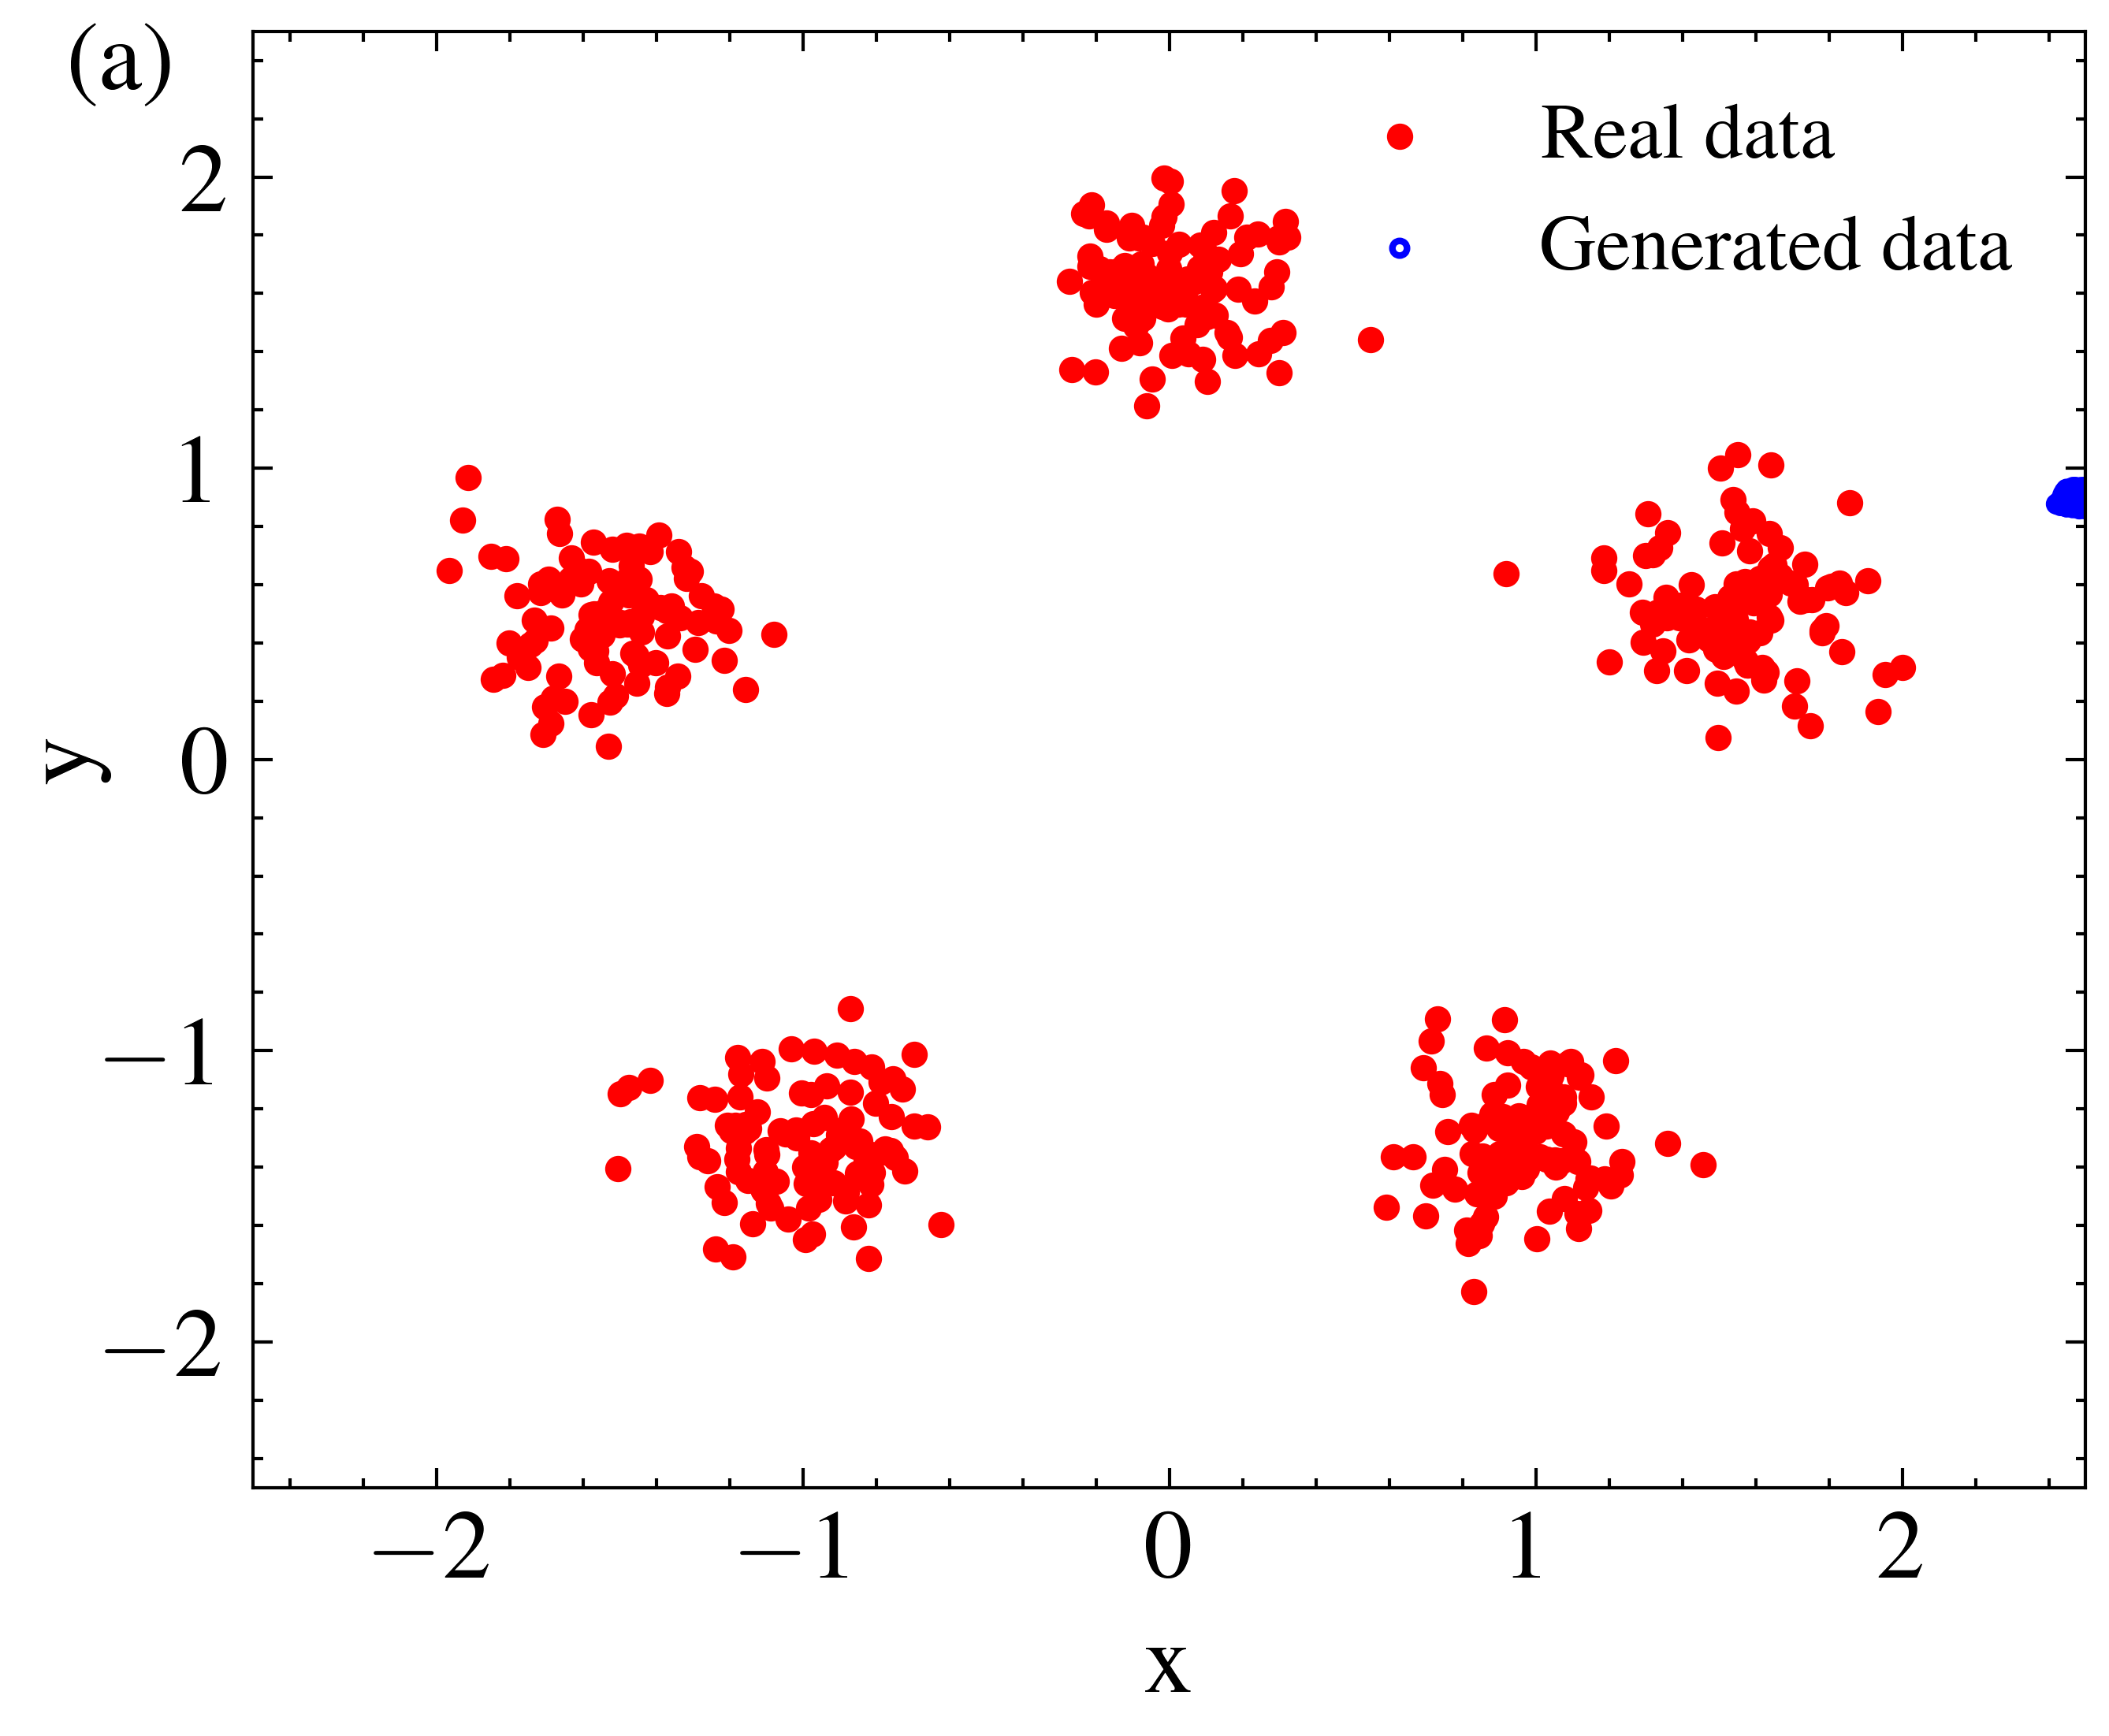

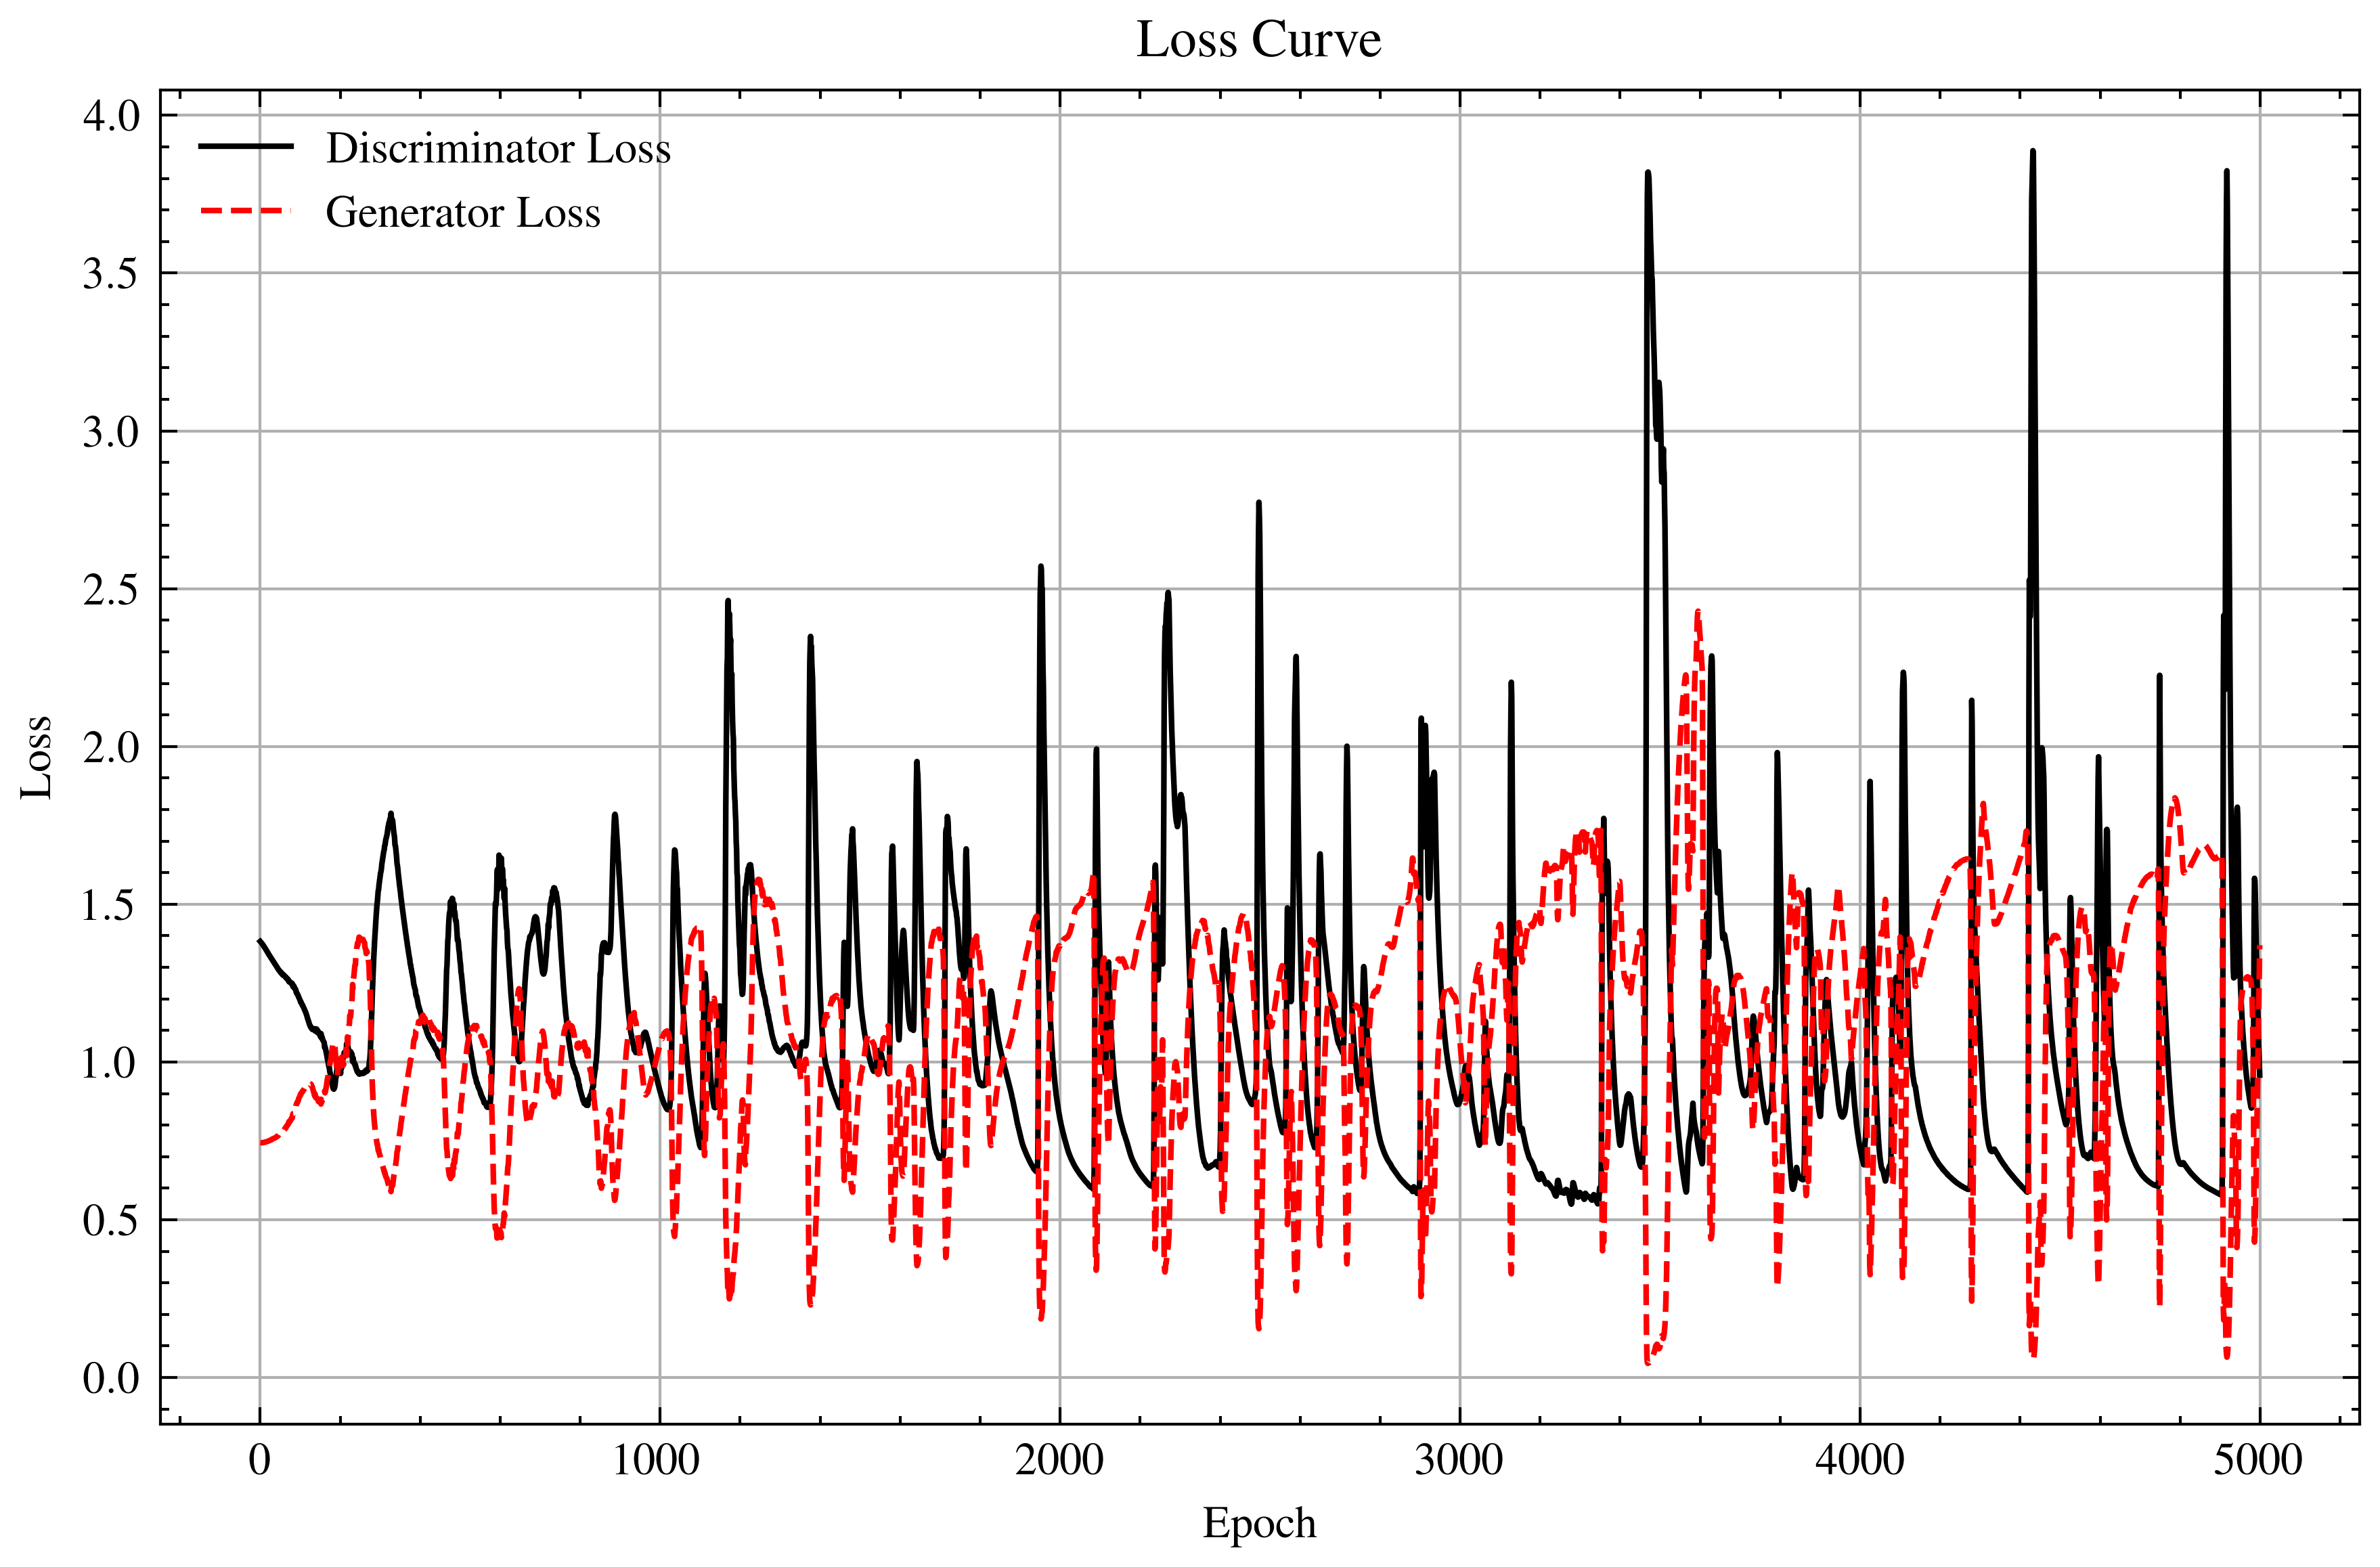

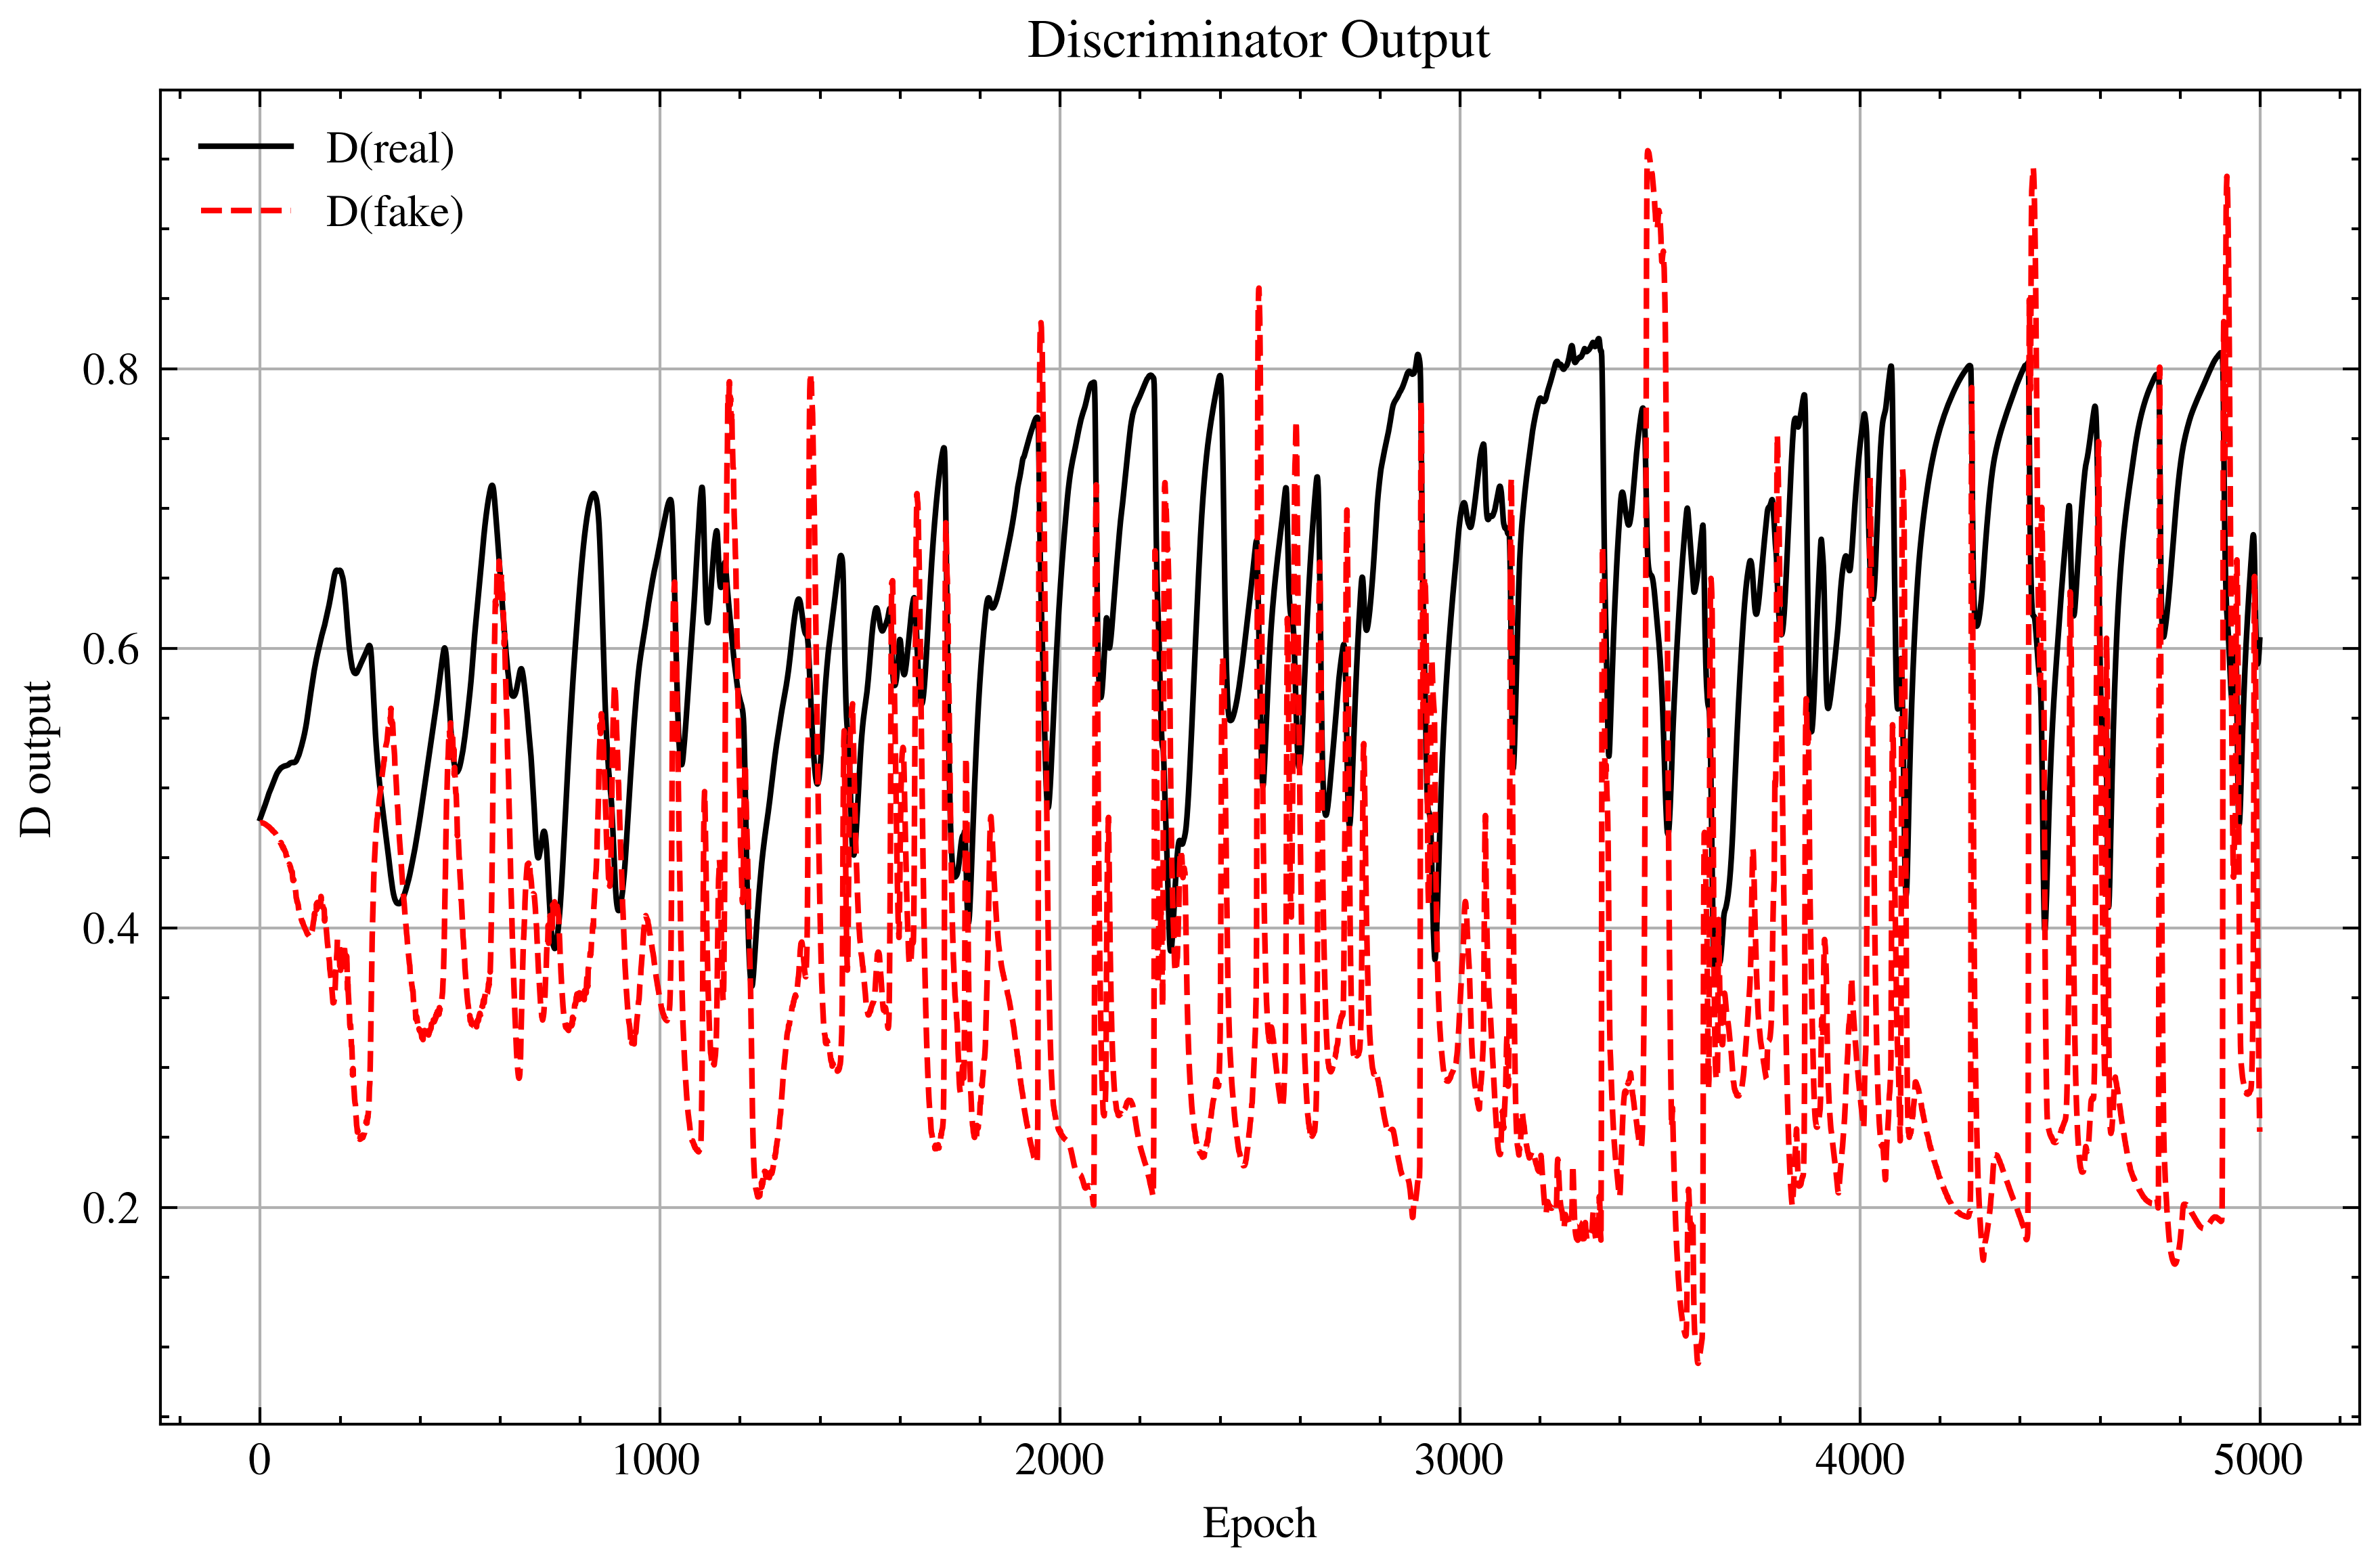

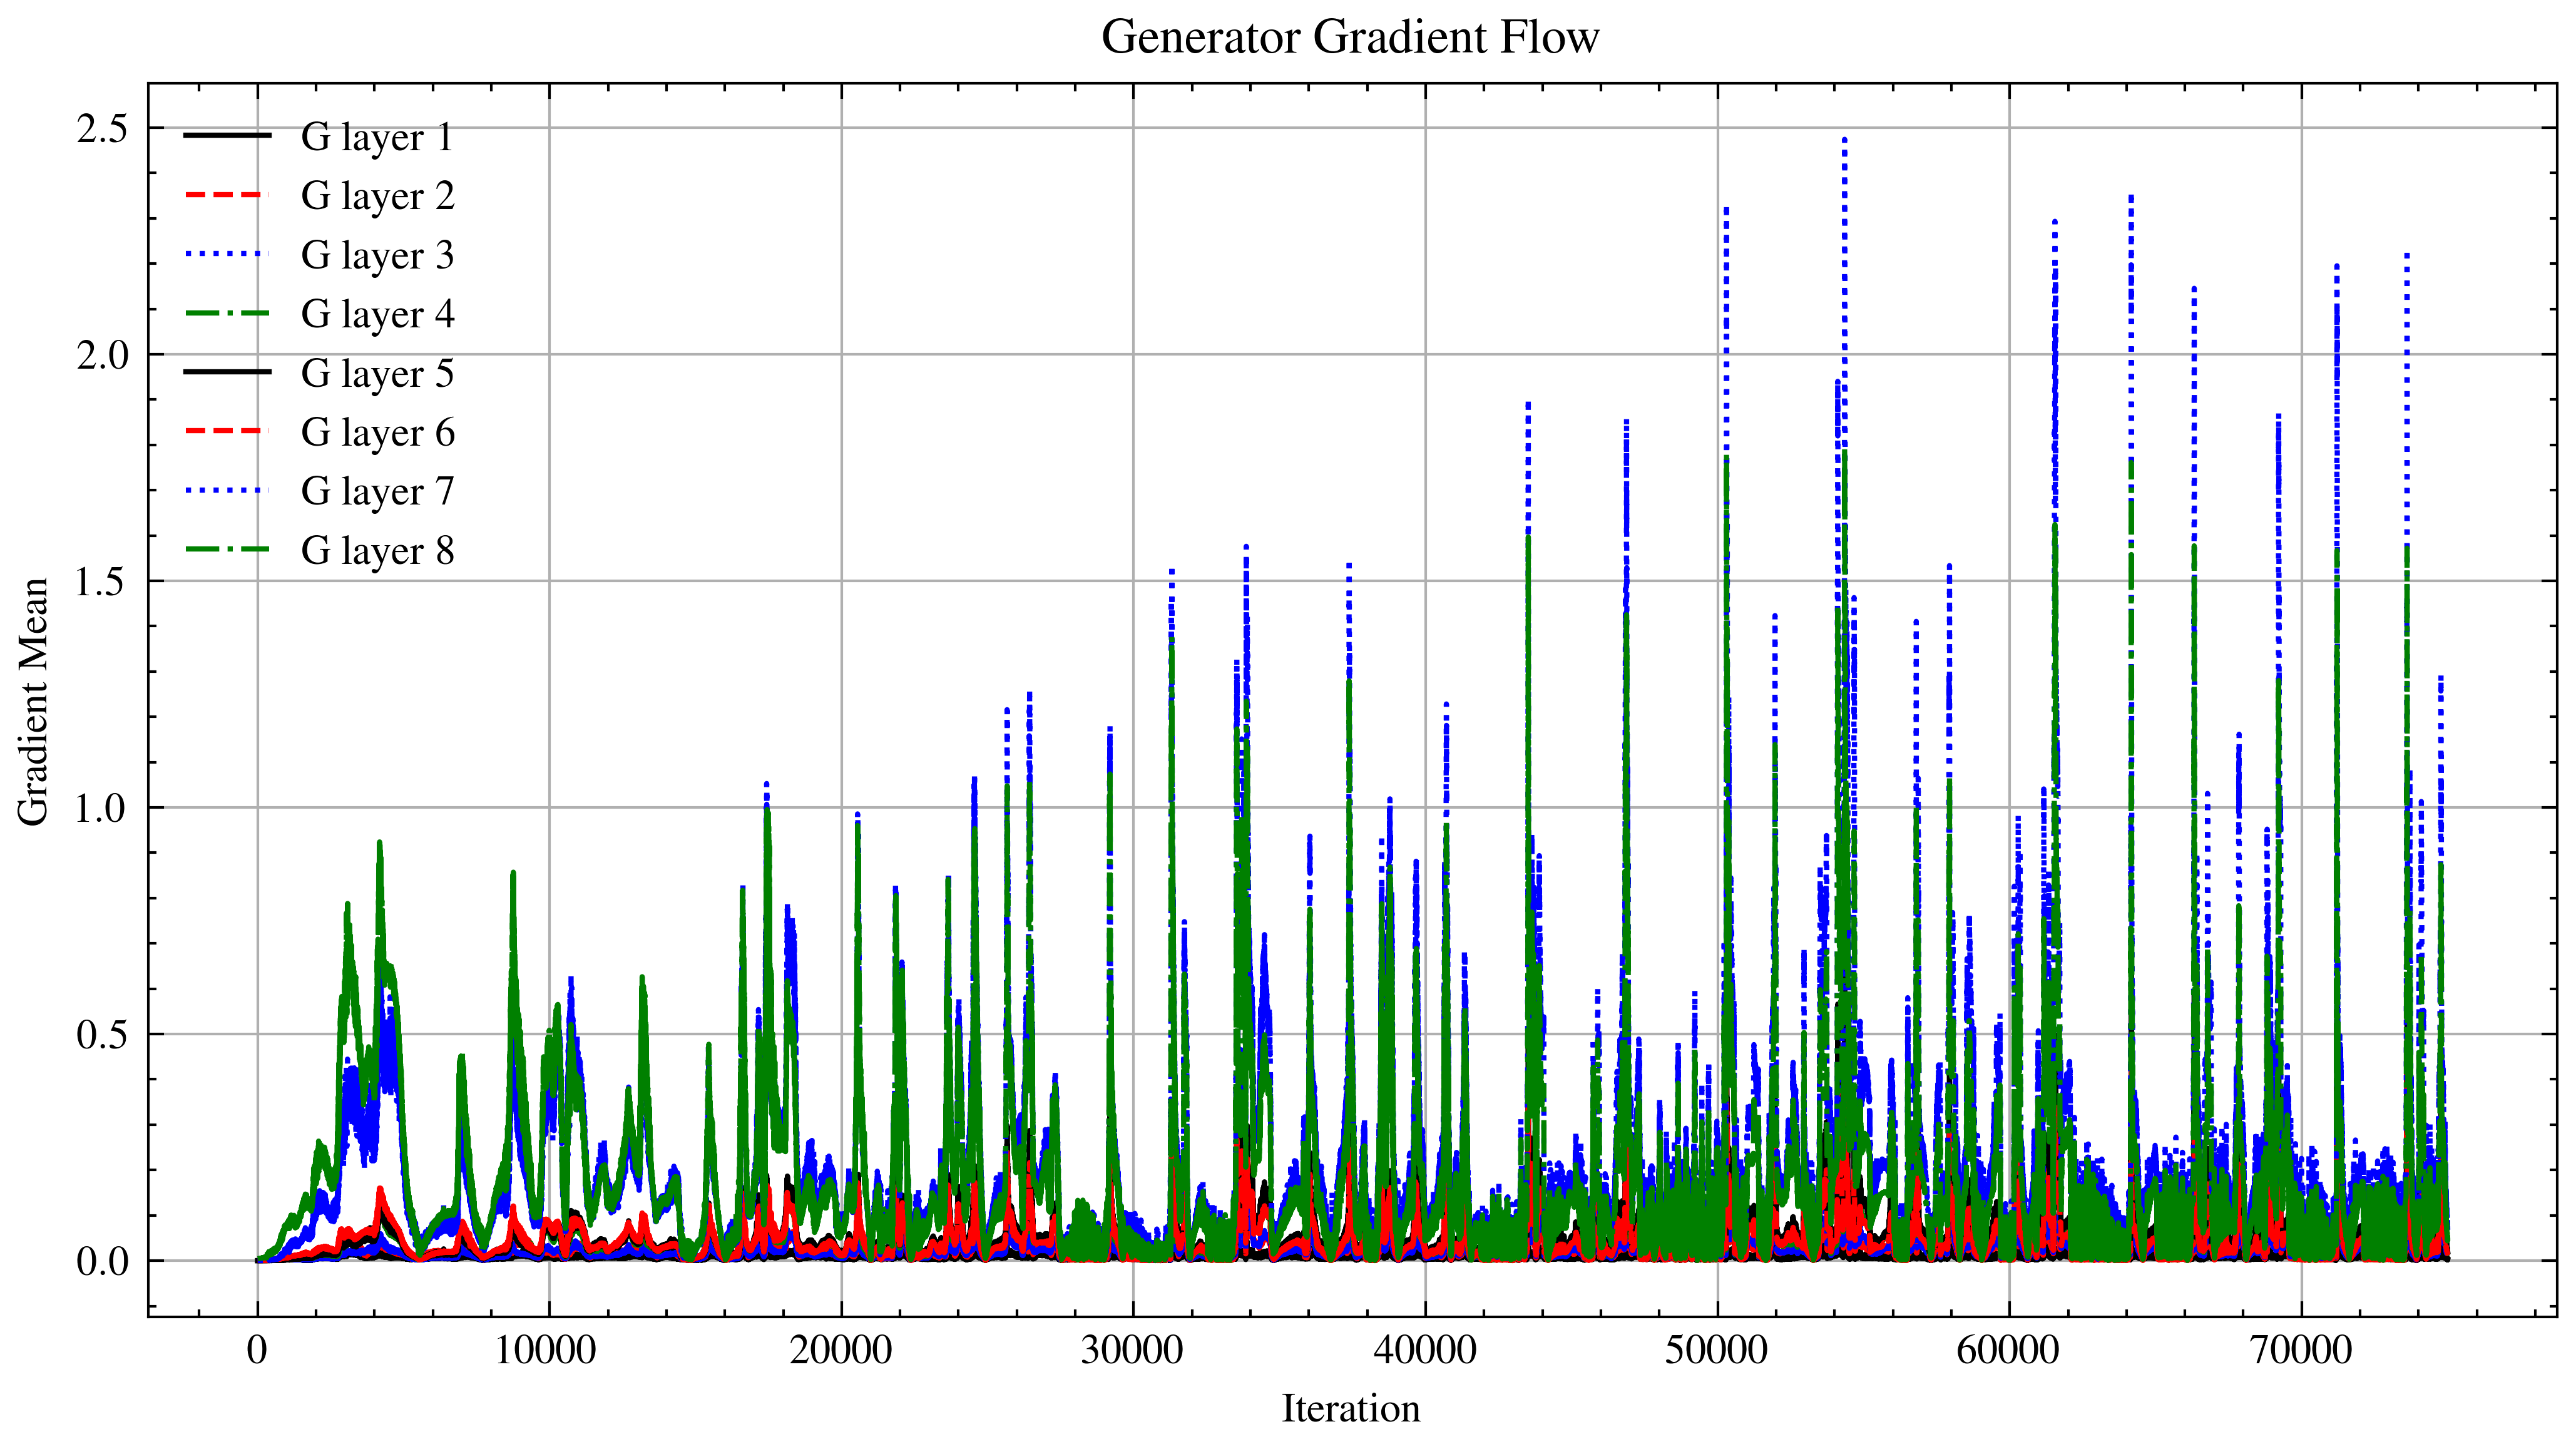

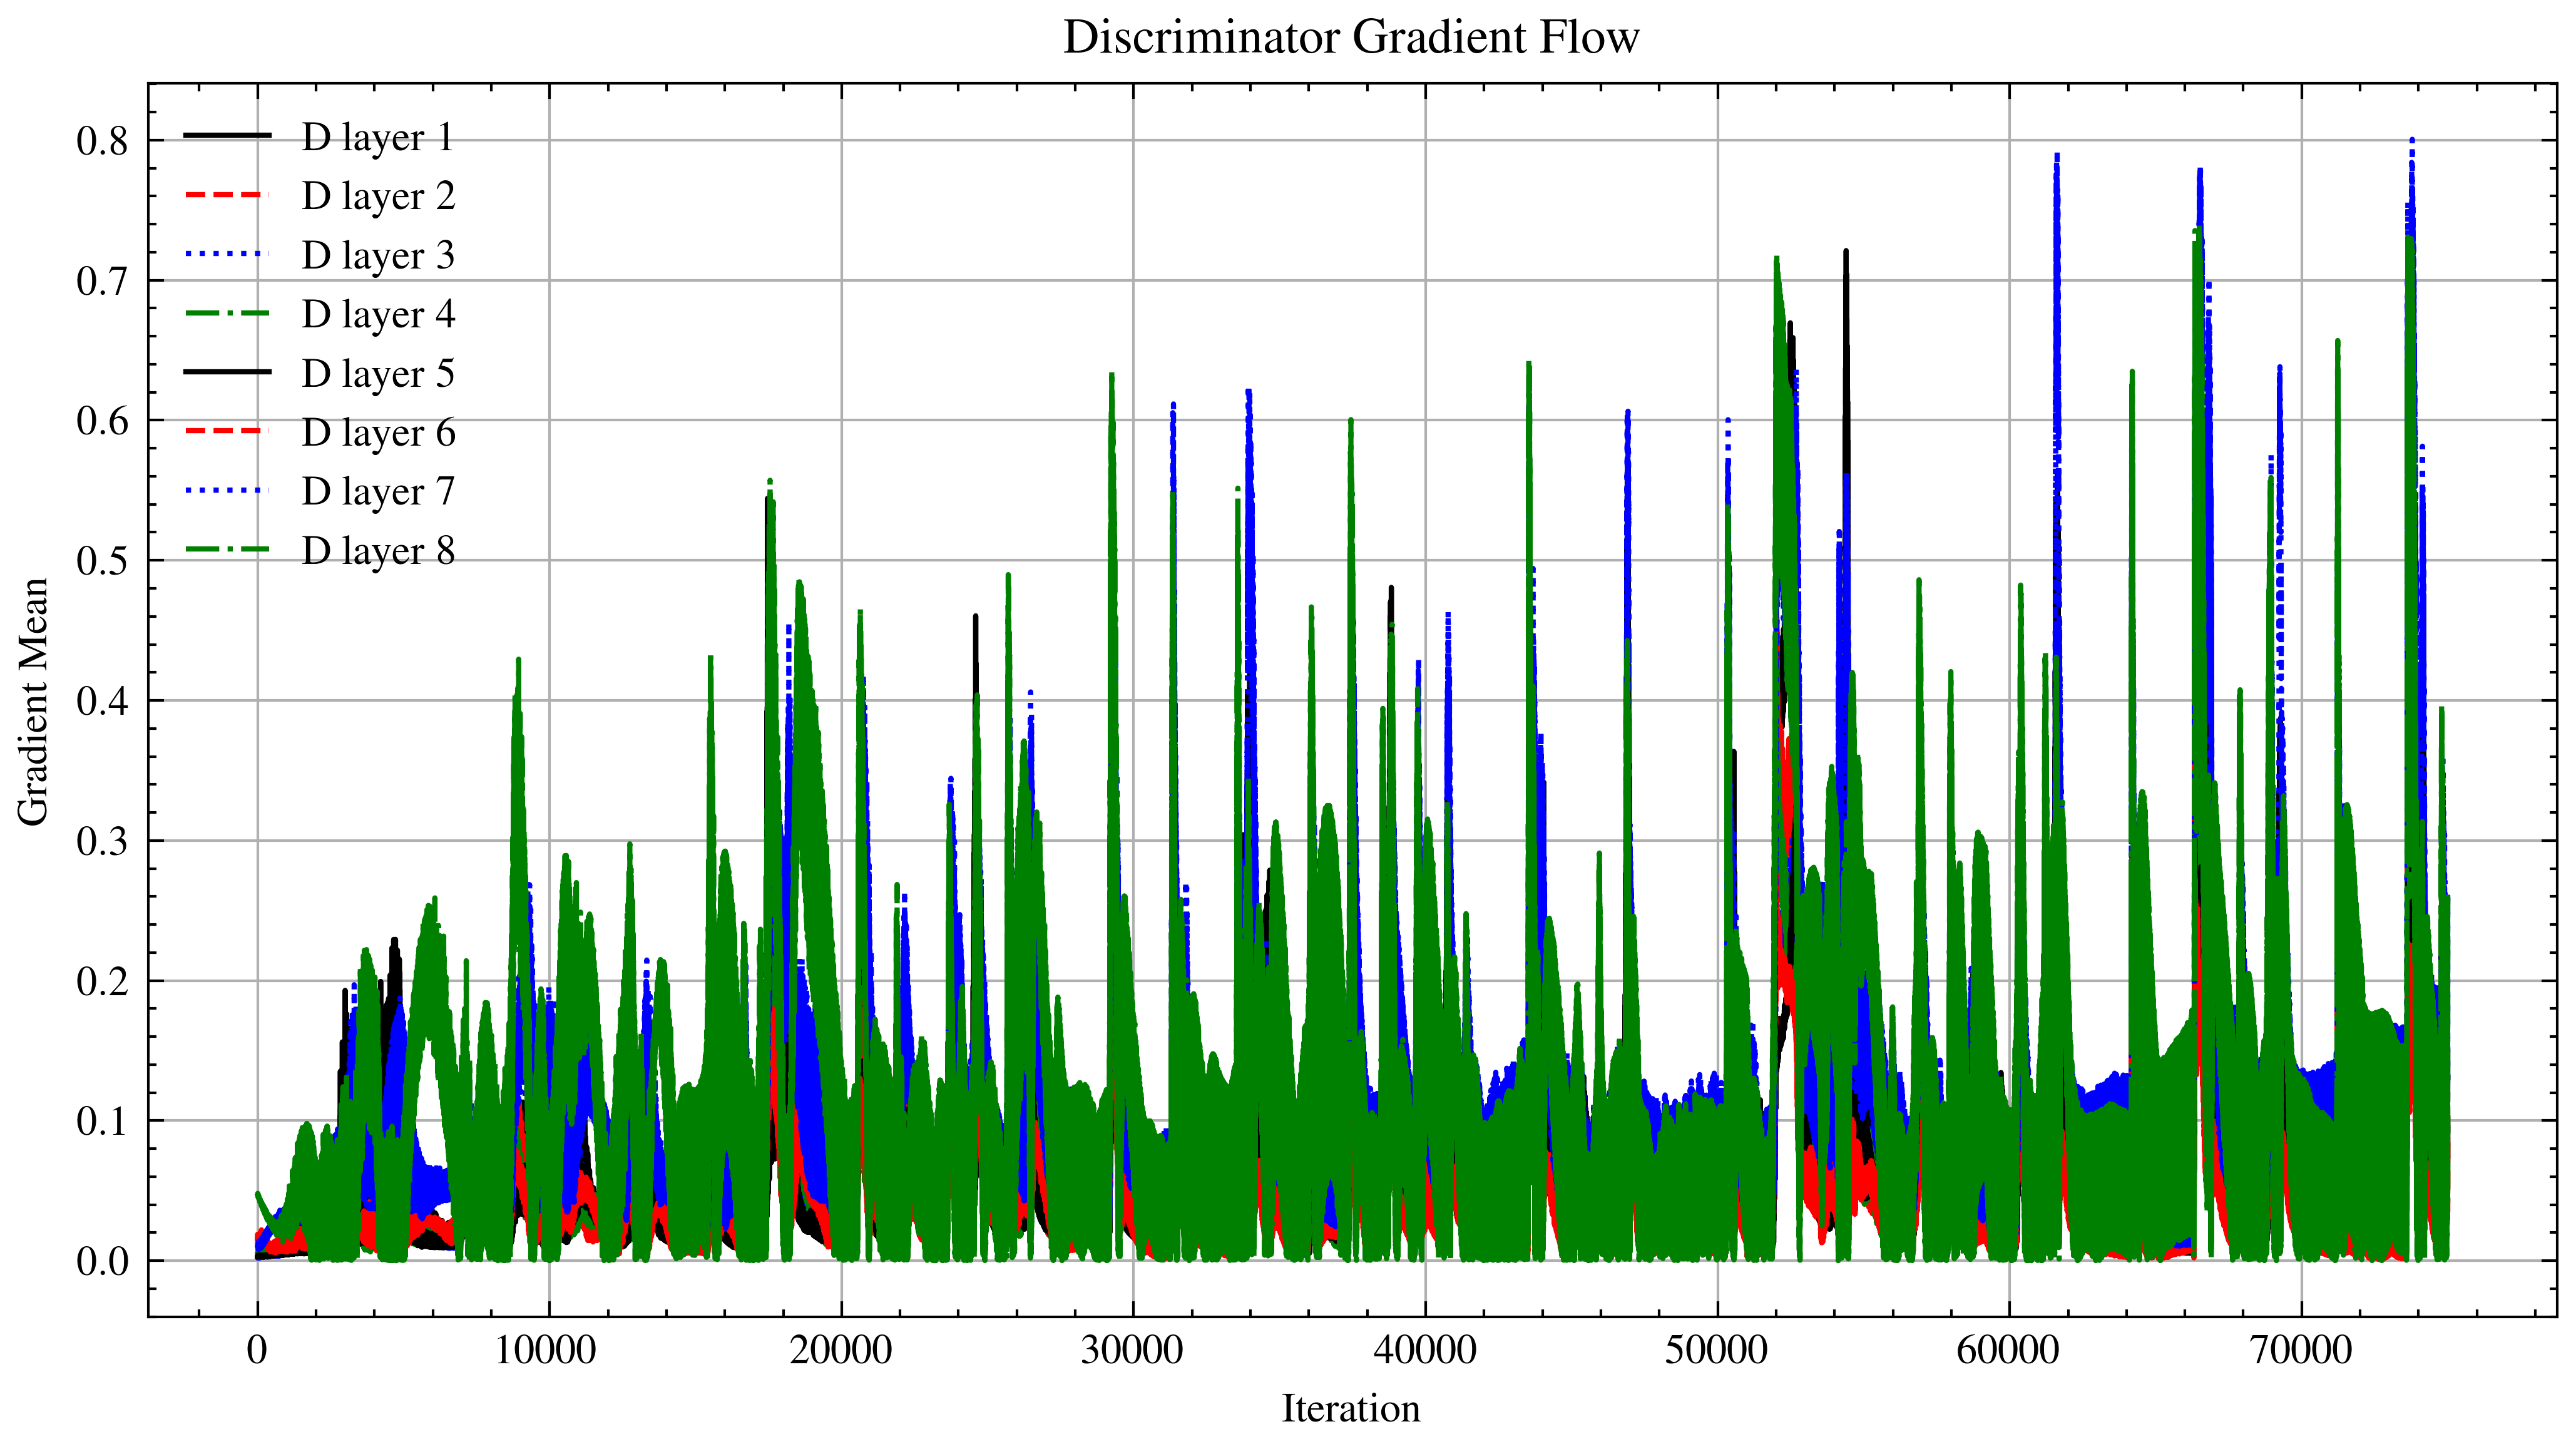

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl

# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)
    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)
    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)
        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    return -torch.mean(torch.log(d_fake + 1e-8))

# 记录每层参数梯度的均值
def record_gradients(model):
    grad_means = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_means.append(param.grad.abs().mean().item())
        else:
            grad_means.append(0.0)
    return grad_means

# 超参数
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
z_dim = 2
x_dim = 2
epochs = 5000

# 初始化模型
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# 优化器
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

# 生成训练数据
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))
X_train = X_train[indices]

# 日志记录
epoch_discriminator_loss = []
epoch_generator_loss = []
epoch_d_real = []
epoch_d_fake = []
g_grads = []
d_grads = []

# 训练循环
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_d_real = []
    batch_d_fake = []
    nb_batches = int(X_train.shape[0] / batch_size)
    
    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        d_loss = discriminator_loss(d_real, d_fake)
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()
        d_grad = record_gradients(discriminator)
        d_grads.append(d_grad)

        d_fake, _ = discriminator(fake_img)
        g_loss = generator_loss(d_fake)
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()
        g_grad = record_gradients(generator)
        g_grads.append(g_grad)

        batch_d_real.append(torch.mean(d_real).item())
        batch_d_fake.append(torch.mean(d_fake).item())
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_d_real.append(np.mean(batch_d_real))
    epoch_d_fake.append(np.mean(batch_d_fake))

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {epoch_discriminator_loss[-1]:.4f}, G Loss: {epoch_generator_loss[-1]:.4f}")

# ================== 可视化 =====================
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
plt.style.use(['science','ieee'])

# 图 (a): 真实数据 vs 生成数据
samples = generator(torch.randn(1000, z_dim)).detach().numpy()
fig, ax = plt.subplots(figsize=(5, 4))
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data',
           marker='o', facecolors='none', edgecolors='blue', s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)
plt.show()

# 图 (b): Loss 曲线
plt.figure(figsize=(6, 4))
plt.plot(epoch_discriminator_loss, label="Discriminator Loss")
plt.plot(epoch_generator_loss, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 图 (c): D_real 和 D_fake
plt.figure(figsize=(6, 4))
plt.plot(epoch_d_real, label="D(real)")
plt.plot(epoch_d_fake, label="D(fake)")
plt.xlabel("Epoch")
plt.ylabel("D output")
plt.title("Discriminator Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 图 (d): Generator Gradients
g_grads = np.array(g_grads)
plt.figure(figsize=(7, 4))
for i in range(g_grads.shape[1]):
    plt.plot(g_grads[:, i], label=f"G layer {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Gradient Mean")
plt.title("Generator Gradient Flow")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 图 (e): Discriminator Gradients
d_grads = np.array(d_grads)
plt.figure(figsize=(7, 4))
for i in range(d_grads.shape[1]):
    plt.plot(d_grads[:, i], label=f"D layer {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Gradient Mean")
plt.title("Discriminator Gradient Flow")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 0: D Loss: 1.5370, G Loss: 1.3057
Epoch 100: D Loss: 0.8246, G Loss: 1.3964
Epoch 200: D Loss: 0.6689, G Loss: 1.5626
Epoch 300: D Loss: 0.8108, G Loss: 1.4689
Epoch 400: D Loss: 0.5904, G Loss: 1.6611
Epoch 500: D Loss: 0.6993, G Loss: 1.4167
Epoch 600: D Loss: 0.9635, G Loss: 1.4481
Epoch 700: D Loss: 0.8655, G Loss: 1.3097
Epoch 800: D Loss: 0.7539, G Loss: 1.4394
Epoch 900: D Loss: 0.8118, G Loss: 1.2925
Epoch 1000: D Loss: 0.8625, G Loss: 1.4064
Epoch 1100: D Loss: 0.8338, G Loss: 1.4402
Epoch 1200: D Loss: 0.8205, G Loss: 1.4378
Epoch 1300: D Loss: 0.9078, G Loss: 1.4010
Epoch 1400: D Loss: 0.9504, G Loss: 1.3202
Epoch 1500: D Loss: 0.8864, G Loss: 1.4413
Epoch 1600: D Loss: 0.9739, G Loss: 1.3652
Epoch 1700: D Loss: 1.0044, G Loss: 1.3043
Epoch 1800: D Loss: 1.0275, G Loss: 1.3348
Epoch 1900: D Loss: 1.0260, G Loss: 1.3346
Epoch 2000: D Loss: 1.0728, G Loss: 1.2326
Epoch 2100: D Loss: 1.0675, G Loss: 1.2842
Epoch 2200: D Loss: 1.0538, G Loss: 1.3182
Epoch 2300: D Loss: 1.0

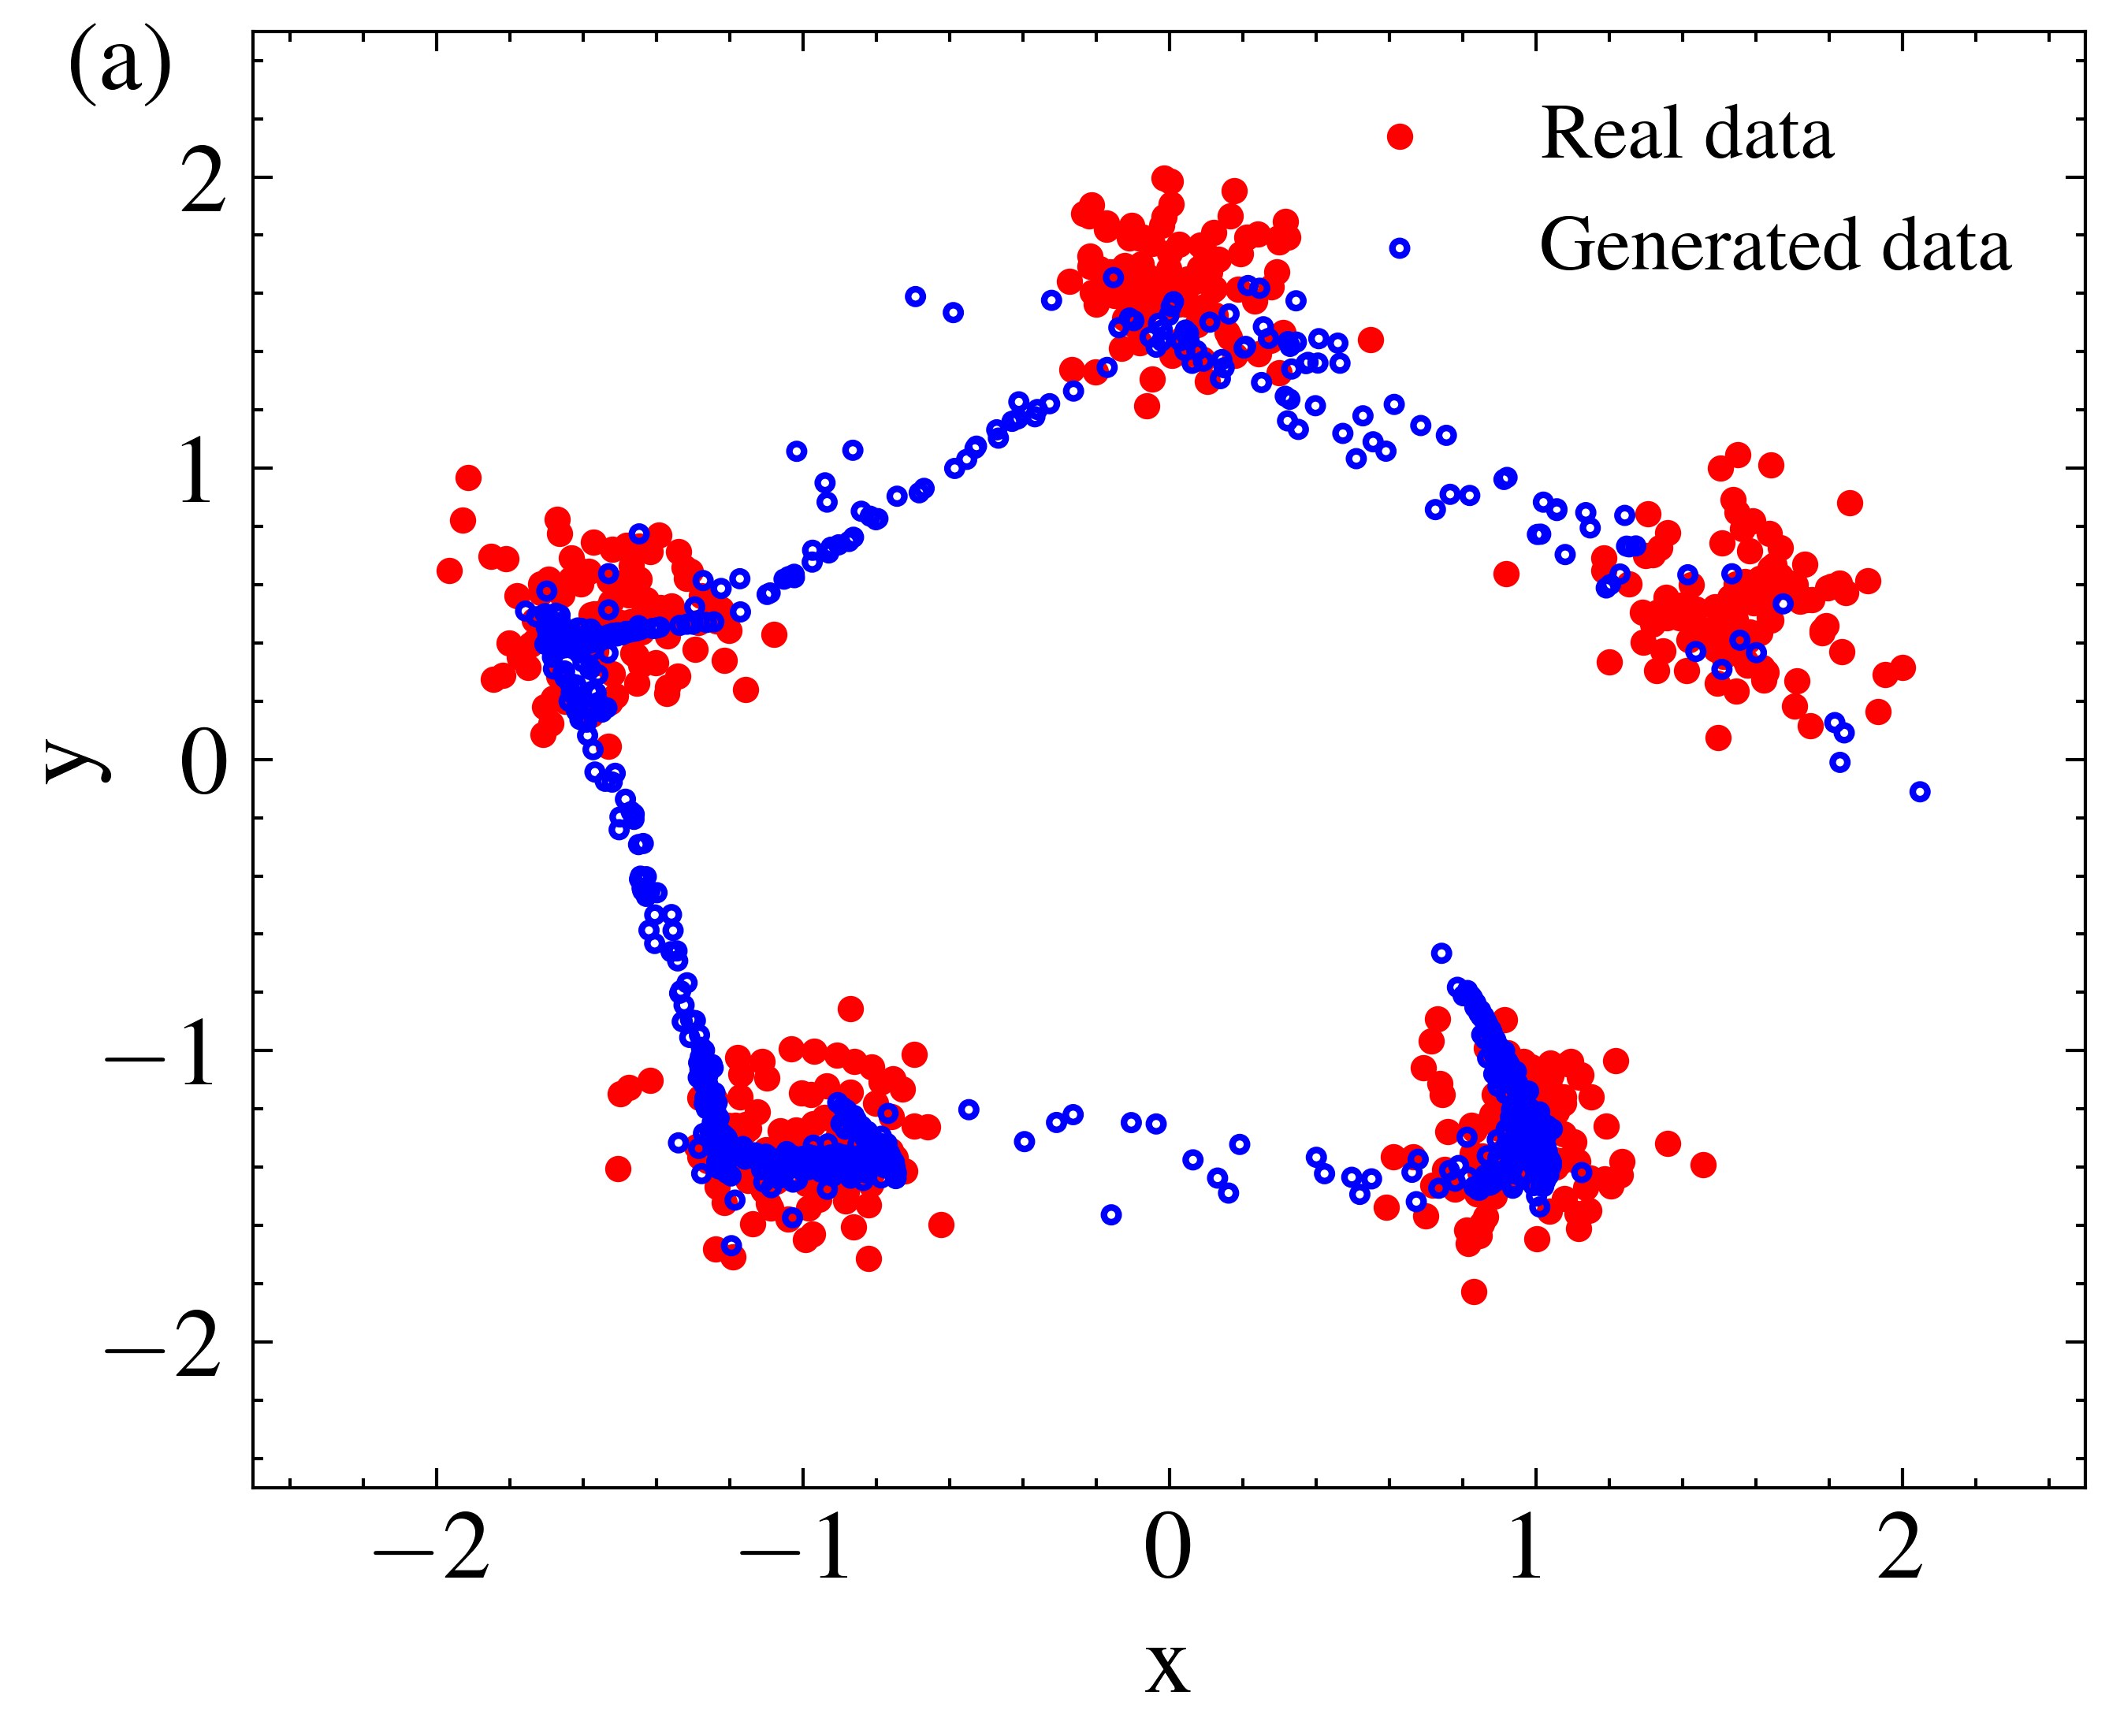

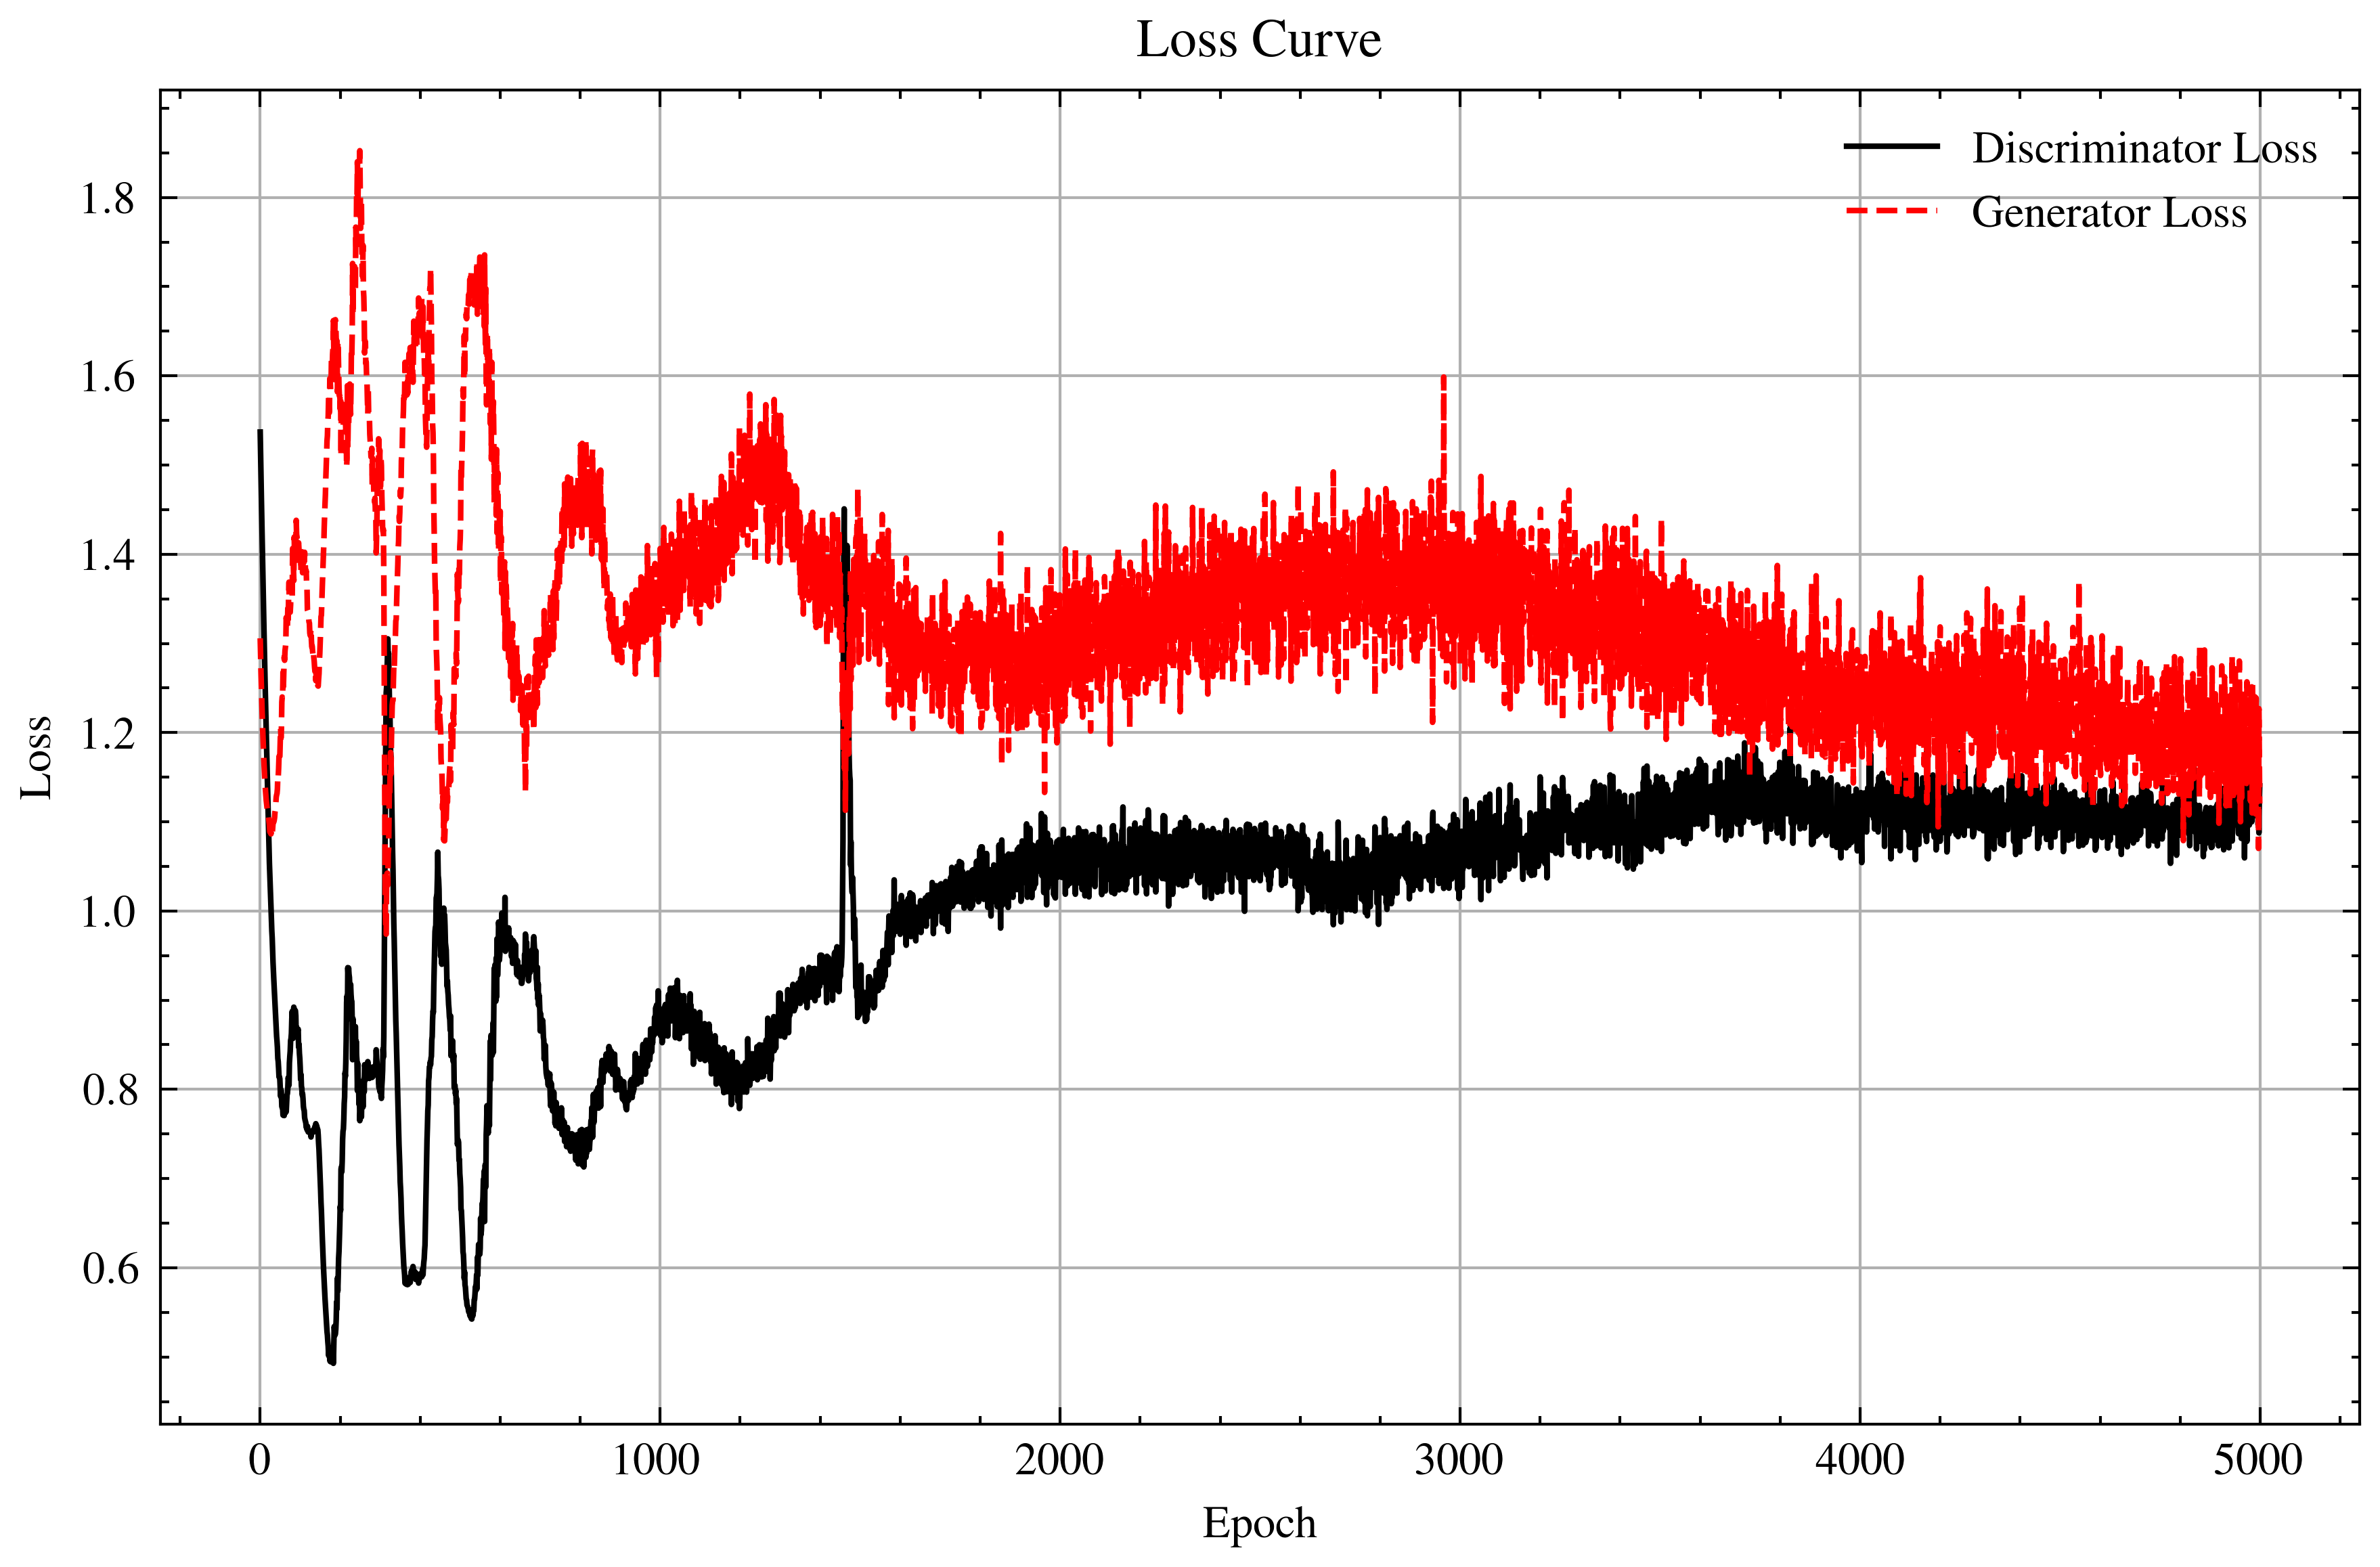

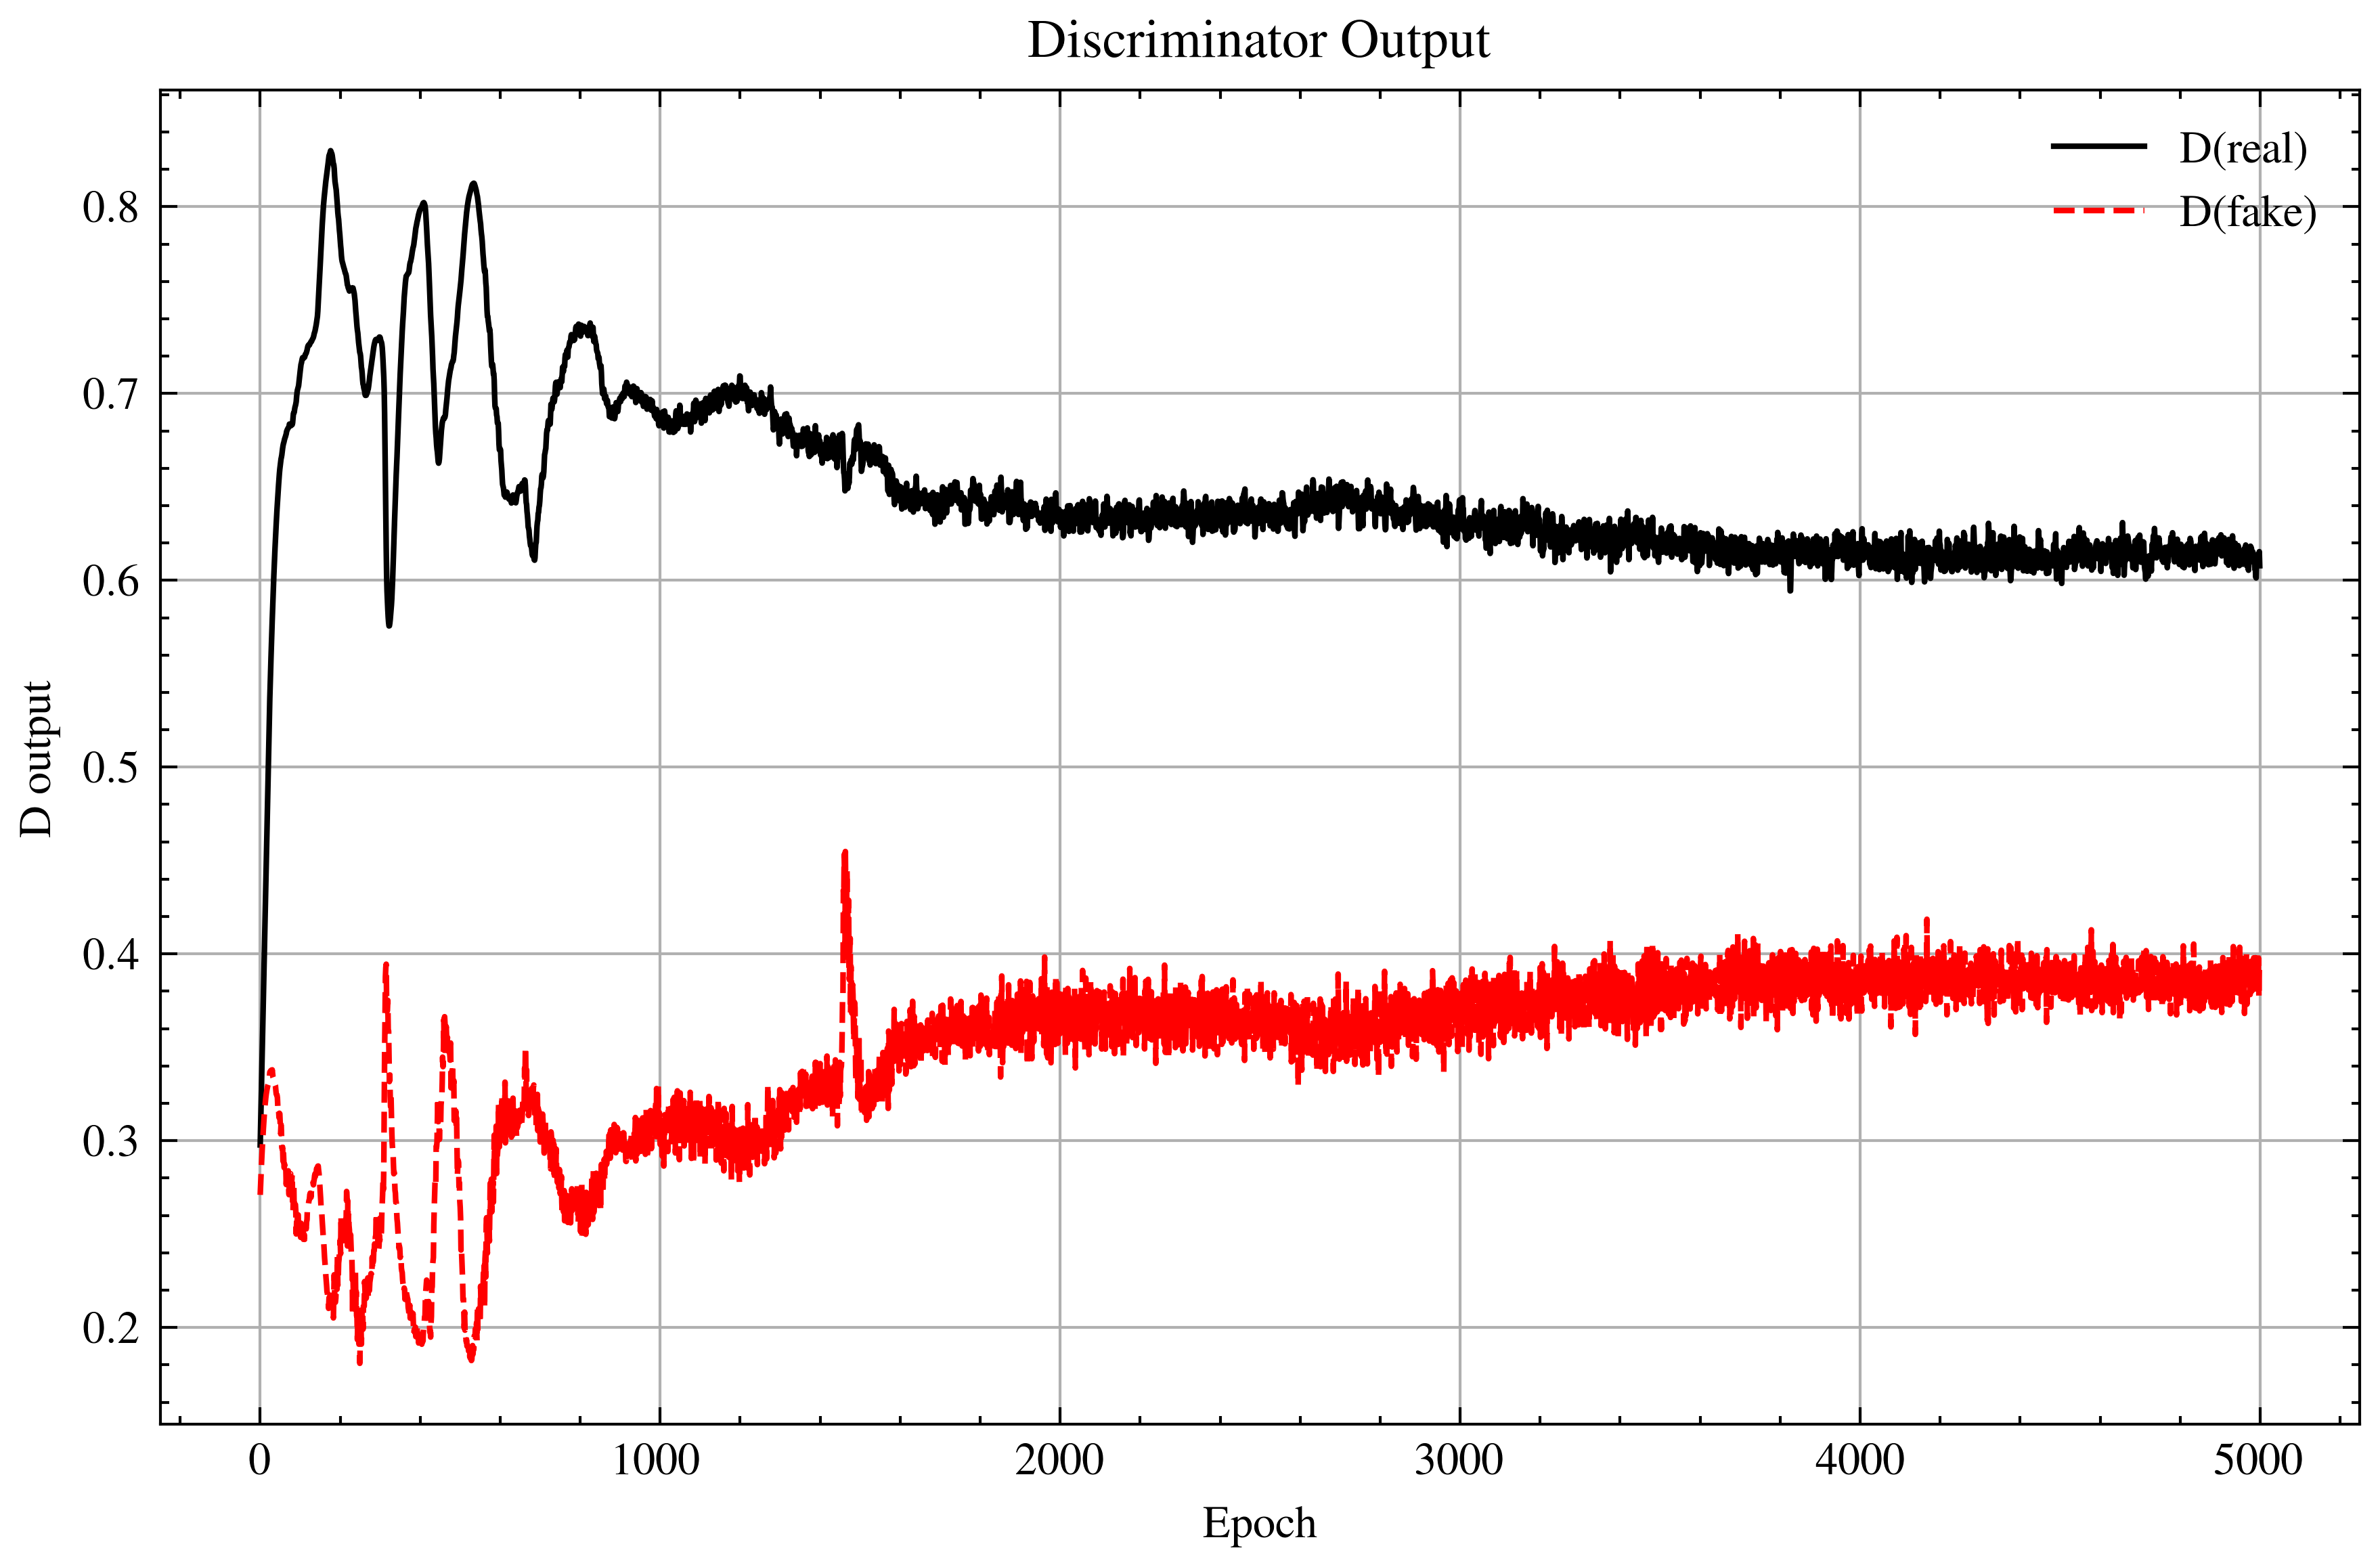

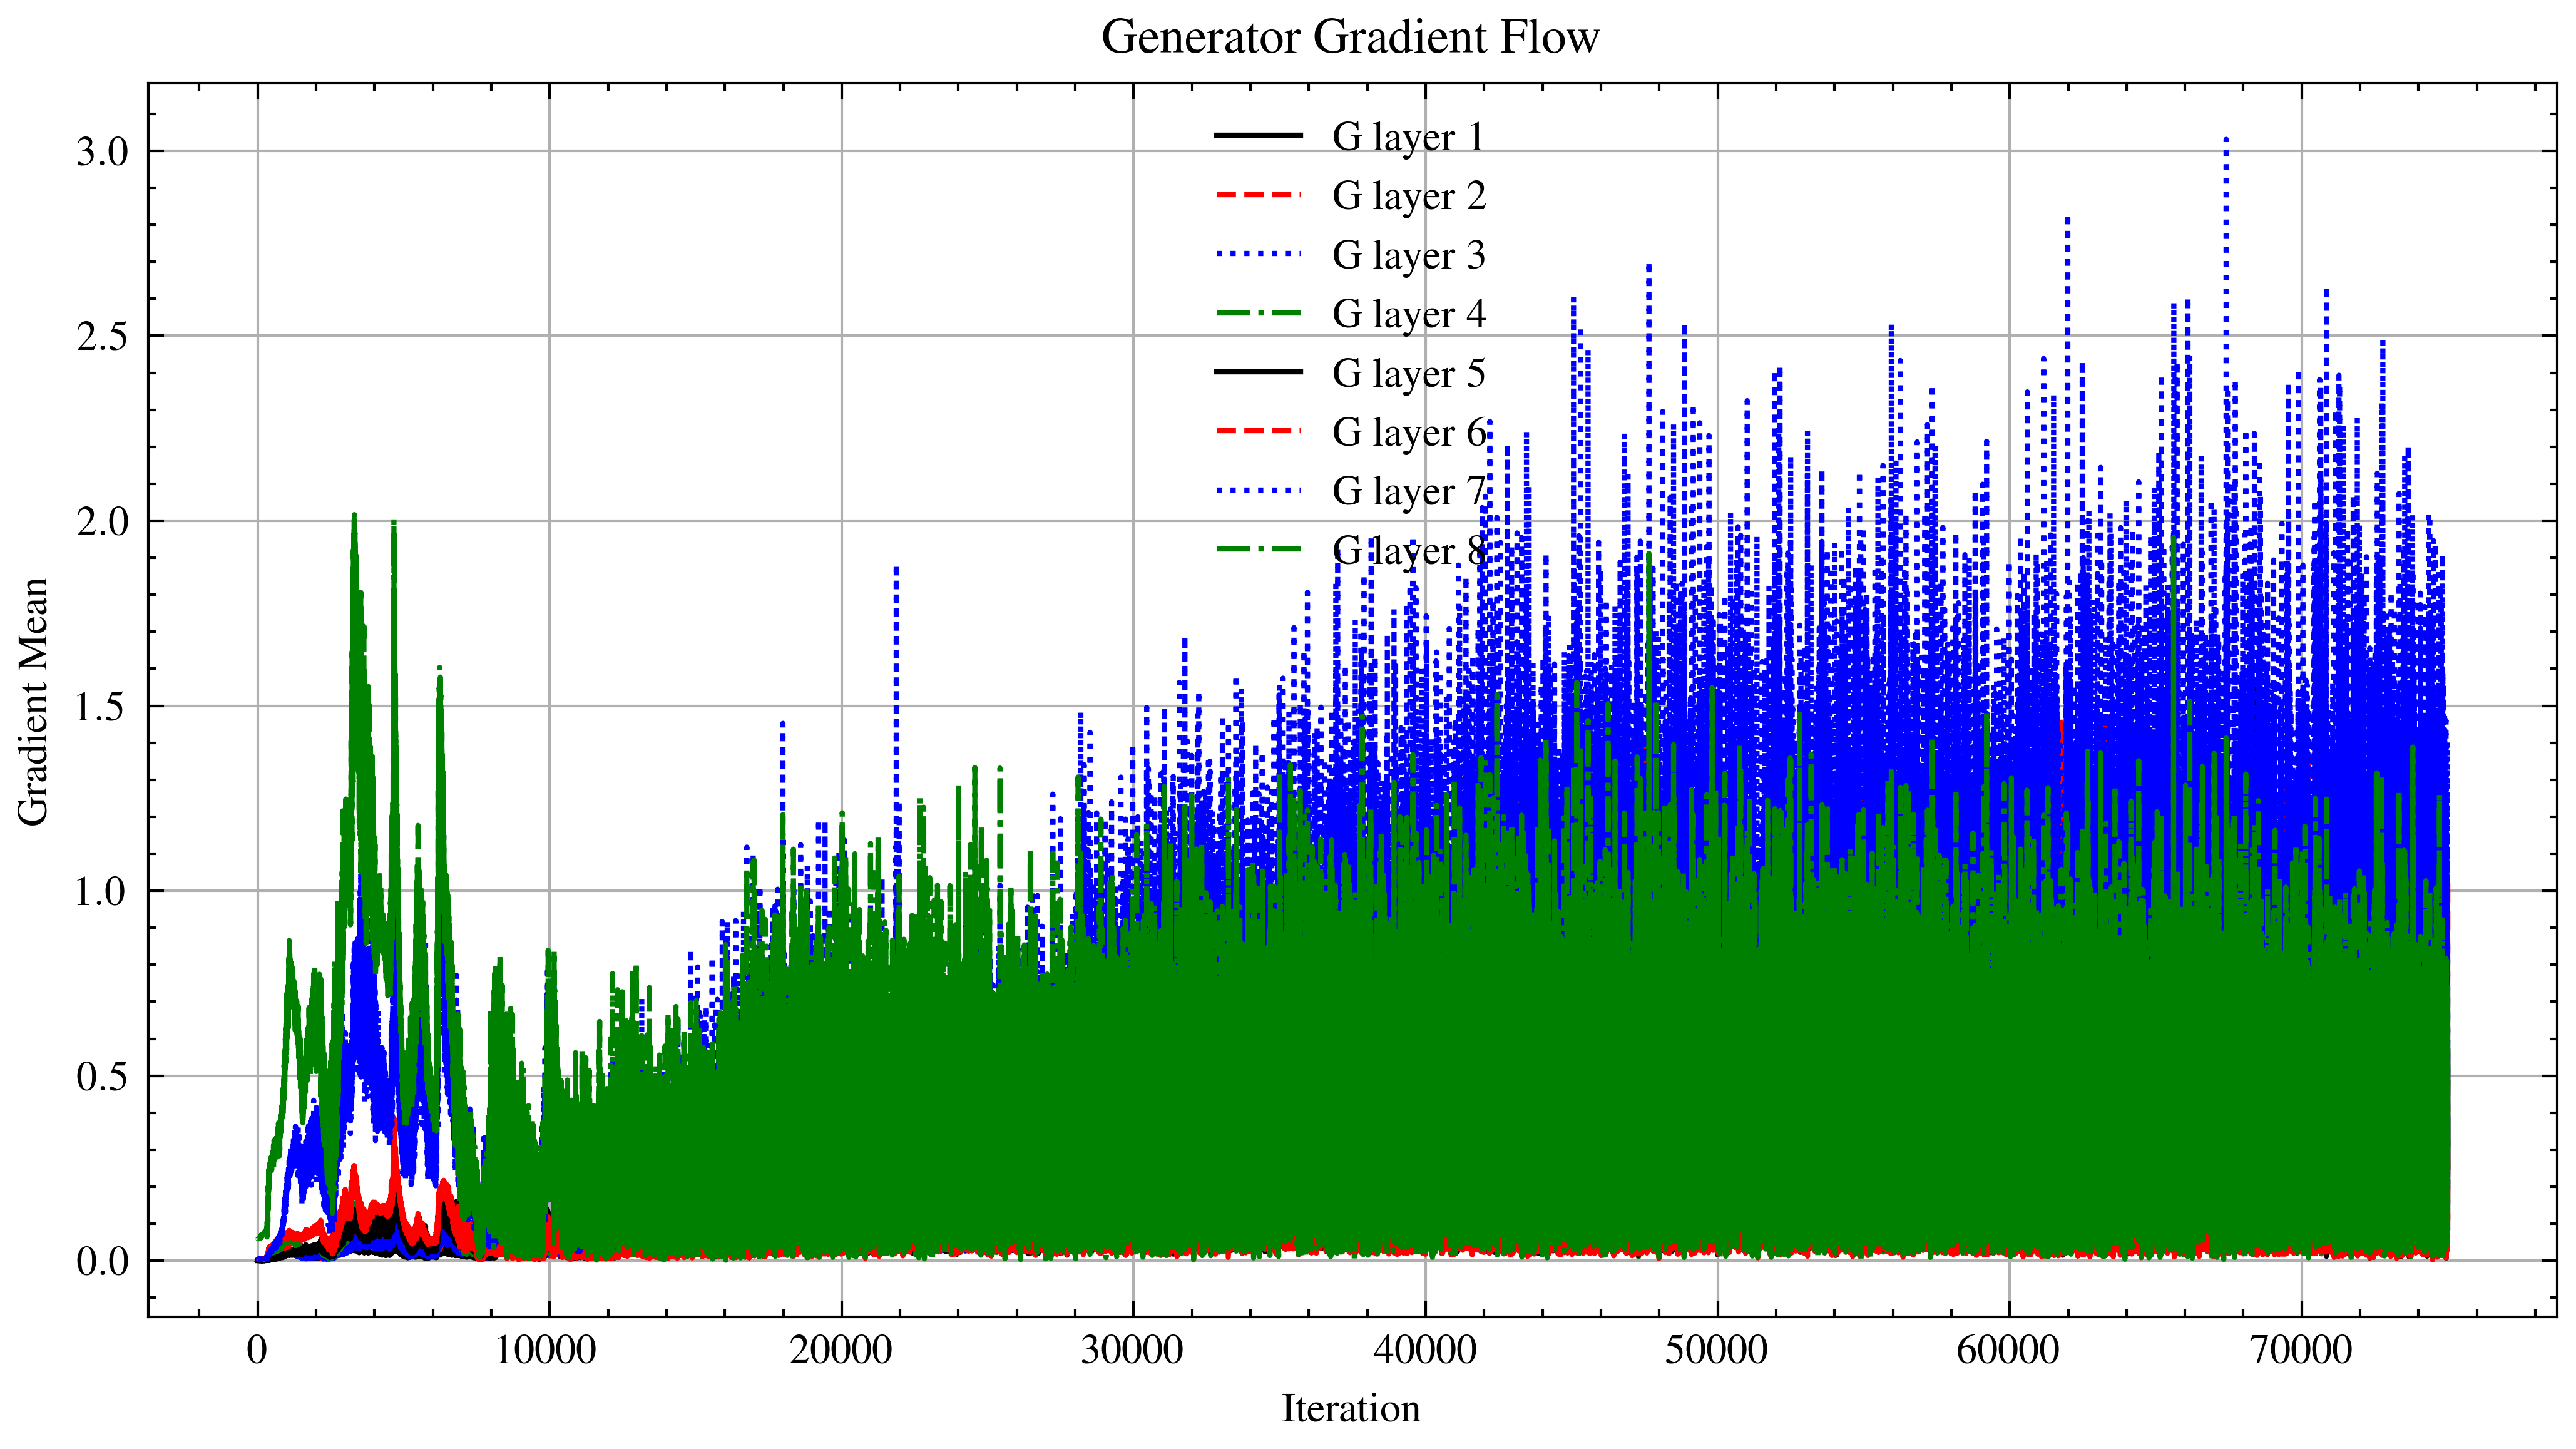

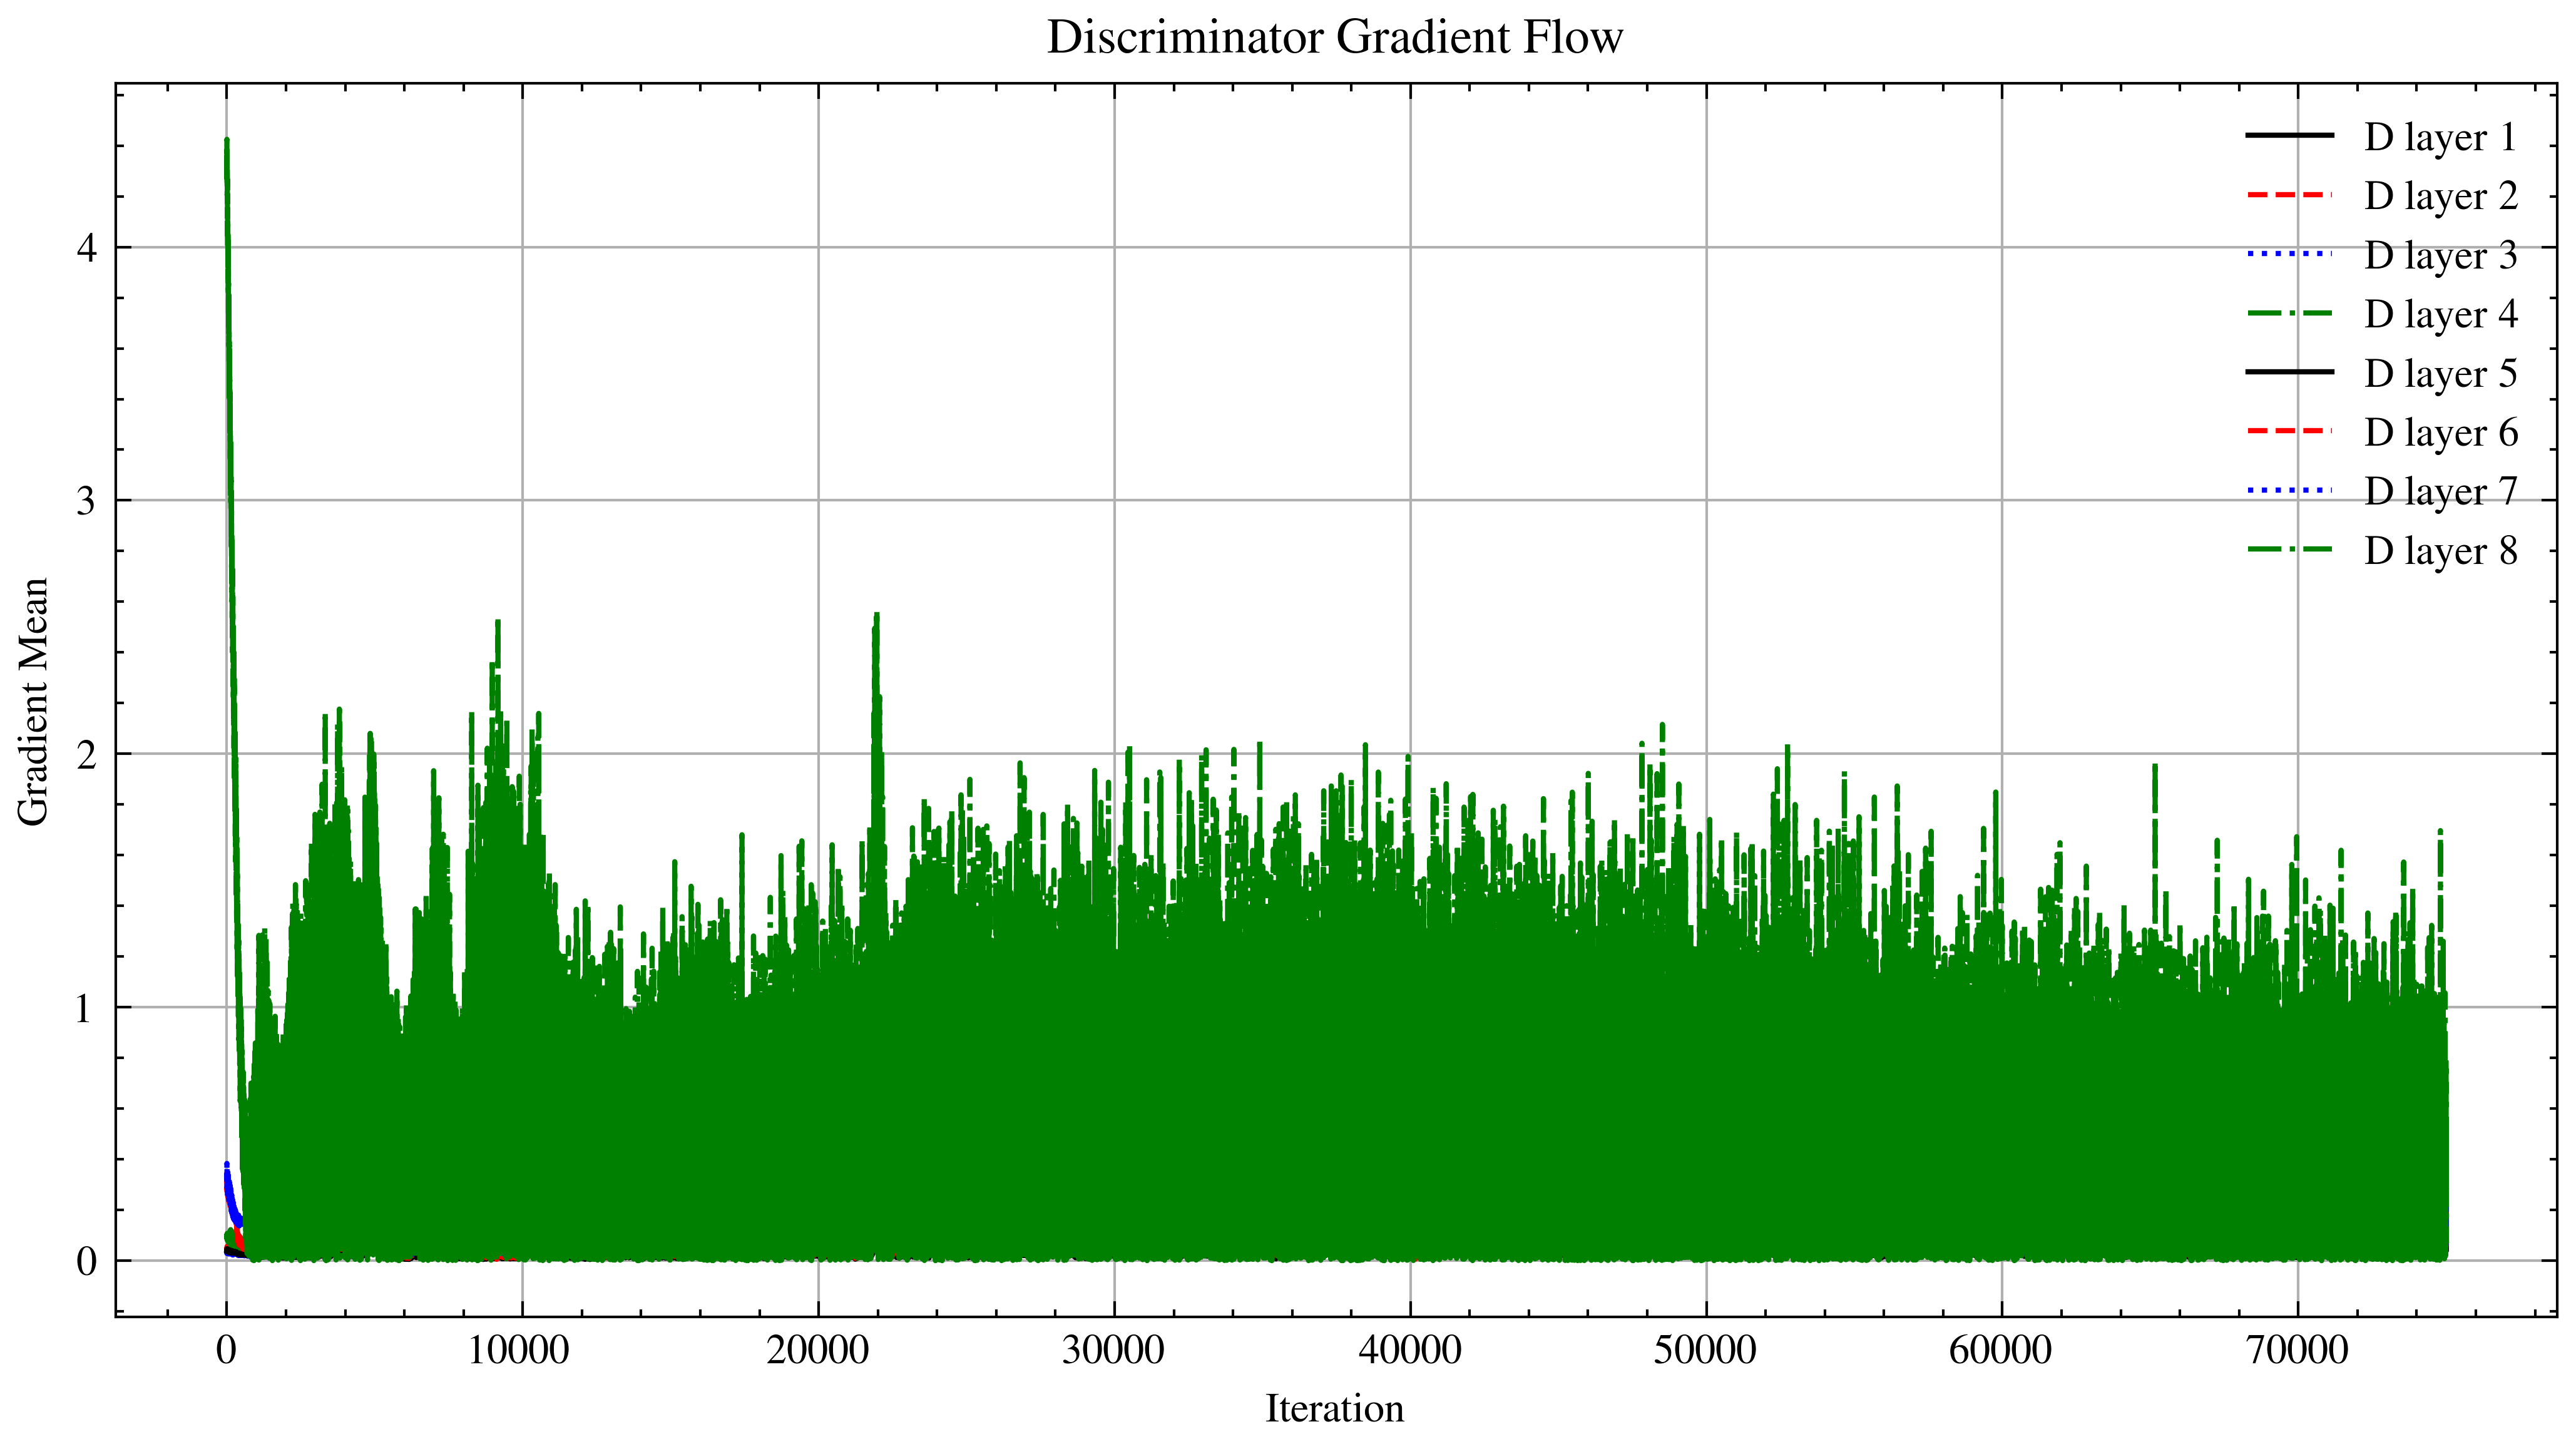

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl

# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)
    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)
    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)
        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4/0.1)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    return -torch.mean(torch.log(d_fake + 1e-8))

# 记录每层参数梯度的均值
def record_gradients(model):
    grad_means = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_means.append(param.grad.abs().mean().item())
        else:
            grad_means.append(0.0)
    return grad_means

# 超参数
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
z_dim = 2
x_dim = 2
epochs = 5000

# 初始化模型
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# 优化器
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

# 生成训练数据
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))
X_train = X_train[indices]

# 日志记录
epoch_discriminator_loss = []
epoch_generator_loss = []
epoch_d_real = []
epoch_d_fake = []
g_grads = []
d_grads = []

# 训练循环
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    batch_d_real = []
    batch_d_fake = []
    nb_batches = int(X_train.shape[0] / batch_size)
    
    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        d_loss = discriminator_loss(d_real, d_fake)
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()
        d_grad = record_gradients(discriminator)
        d_grads.append(d_grad)

        d_fake, _ = discriminator(fake_img)
        g_loss = generator_loss(d_fake)
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()
        g_grad = record_gradients(generator)
        g_grads.append(g_grad)

        batch_d_real.append(torch.mean(d_real).item())
        batch_d_fake.append(torch.mean(d_fake).item())
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))
    epoch_d_real.append(np.mean(batch_d_real))
    epoch_d_fake.append(np.mean(batch_d_fake))

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {epoch_discriminator_loss[-1]:.4f}, G Loss: {epoch_generator_loss[-1]:.4f}")

# ================== 可视化 =====================
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
plt.style.use(['science','ieee'])

# 图 (a): 真实数据 vs 生成数据
samples = generator(torch.randn(1000, z_dim)).detach().numpy()
fig, ax = plt.subplots(figsize=(5, 4))
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data',
           marker='o', facecolors='none', edgecolors='blue', s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)
plt.show()

# 图 (b): Loss 曲线
plt.figure(figsize=(6, 4))
plt.plot(epoch_discriminator_loss, label="Discriminator Loss")
plt.plot(epoch_generator_loss, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 图 (c): D_real 和 D_fake
plt.figure(figsize=(6, 4))
plt.plot(epoch_d_real, label="D(real)")
plt.plot(epoch_d_fake, label="D(fake)")
plt.xlabel("Epoch")
plt.ylabel("D output")
plt.title("Discriminator Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 图 (d): Generator Gradients
g_grads = np.array(g_grads)
plt.figure(figsize=(7, 4))
for i in range(g_grads.shape[1]):
    plt.plot(g_grads[:, i], label=f"G layer {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Gradient Mean")
plt.title("Generator Gradient Flow")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 图 (e): Discriminator Gradients
d_grads = np.array(d_grads)
plt.figure(figsize=(7, 4))
for i in range(d_grads.shape[1]):
    plt.plot(d_grads[:, i], label=f"D layer {i+1}")
plt.xlabel("Iteration")
plt.ylabel("Gradient Mean")
plt.title("Discriminator Gradient Flow")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()